# Serialized PE metadata under low false-positive constraints

Reproducible evaluation of numerical PE features, serialized PE representations, CodeBERT, calibration, fusion, threshold transfer, and fixed-FPR uncertainty on EMBER2024.


In [1]:
import os, sys, json, re, gc, math, time, random, zipfile
from pathlib import Path
from collections import Counter
from contextlib import nullcontext

os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm
from scipy.special import expit
from scipy.stats import beta
from scipy.optimize import minimize_scalar
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
import joblib
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers.utils import logging as transformers_logging
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import logging as hub_logging
import lightgbm as lgb
from thrember.features import PEFeatureExtractor

transformers_logging.set_verbosity_error()
hub_logging.set_verbosity_error()


## Data and model parameters

The official EMBER2024 train-period shards span 24 September 2023 through 21 September 2024. The later-period shards span 22 September through 14 December 2024. Records are deduplicated by SHA-256 before sampling. Six disjoint roles are used for fitting, tuning, calibration, deployment-threshold selection, same-period evaluation, and later-period evaluation.


In [2]:
ROOT = Path(".")
SOURCE_DIR = ROOT / "ember2024"
ZIP_DIR = SOURCE_DIR / "archives"
EXTRACT_DIR = SOURCE_DIR / "jsonl"
DATA_DIR = ROOT / "data"
FIGURES_DIR = ROOT / "figures"
MODELS_DIR = ROOT / "models"

DATASET_REPO = "joyce8/EMBER2024"
DATASET_REVISION = "3d23efef7c0f0b702c5024400cfff4c3744a3832"
MODEL_NAME = "microsoft/codebert-base"
MODEL_REVISION = "3b0952feddeffad0063f274080e3c23d75e7eb39"
EXPECTED_SHARDS = {"train": 52, "test": 12}
FILE_TYPES = ("Win32", "Win64", "Dot_Net")
COUNTS_PER_FORMAT = dict(fit=18000, tune=2000, calibration=4000, threshold=20000, same_period=10000)
TEST_PER_FORMAT = 10000
SAMPLING_SEED = 31001
SPLIT_SEED = 31002
TRAINING_SEEDS = (2026, 2027, 2028)
FREEZING = ("partial", "unfrozen")
MAX_LENGTH = 512
BATCH_SIZE = 16
EVAL_BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
PATIENCE = 3
MIN_DELTA = 1e-4
NUM_WORKERS = 0
CPU_THREADS = min(16, os.cpu_count() or 1)
FPR_TARGETS = np.array([0.001, 0.005, 0.01, 0.05])
TFIDF_C_GRID = (0.1, 1.0, 10.0, 30.0, 100.0, 300.0, 1000.0)
TFIDF_MAX_FEATURES = 200000
FUSION_WEIGHTS = np.unique(np.r_[np.linspace(0, 1, 21), 0.01, 0.02, 0.03, 0.04])
BOOTSTRAP_REPS = 1000
THRESHOLD_REPS = 1000
REFIT_REPS = 200
BOOTSTRAP_SEED = 31003
BENCHMARK_REPEATS = 5
BENCHMARK_SAMPLES = 256
BENCHMARK_SINGLE_SAMPLES = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_BF16 = DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
torch.set_num_threads(CPU_THREADS)
for directory in (ZIP_DIR, EXTRACT_DIR, DATA_DIR, FIGURES_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
data_files, figure_files = set(), set()


In [3]:
def save_table(frame, name):
    path = DATA_DIR / f"{name}.csv"
    frame.to_csv(path, index=False, float_format="%.17g")
    data_files.add(path.name)
    return frame

def save_json(value, name):
    path = DATA_DIR / f"{name}.json"
    path.write_text(json.dumps(value, indent=2), encoding="utf-8")
    data_files.add(path.name)

def save_figure(fig, name):
    path = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight")
    figure_files.add(path.name)
    plt.show()
    plt.close(fig)


In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def amp_context():
    return torch.autocast("cuda", dtype=torch.bfloat16) if USE_BF16 else nullcontext()

def sync_device():
    if DEVICE.type == "cuda": torch.cuda.synchronize()


## Source cohorts

The six public archives are downloaded at the pinned EMBER2024 revision and expanded into weekly JSONL shards. Only labelled records are eligible for sampling.


In [5]:
def raw_files(ft, split):
    return sorted(EXTRACT_DIR.rglob(f"*_{ft}_{split}.jsonl"))

input_rows = []
for split in ("train", "test"):
    for ft in FILE_TYPES:
        name = f"{ft}_{split}.zip"
        archive = Path(hf_hub_download(DATASET_REPO, name, repo_type="dataset", revision=DATASET_REVISION, local_dir=ZIP_DIR))
        if len(raw_files(ft, split)) != EXPECTED_SHARDS[split]:
            with zipfile.ZipFile(archive) as z:
                z.extractall(EXTRACT_DIR)
        paths = raw_files(ft, split)
        assert len(paths) == EXPECTED_SHARDS[split]
        for path in paths:
            dates = re.findall(r"\d{4}-\d{2}-\d{2}", path.name)
            input_rows.append(dict(file_type=ft, source_split=split, source_file=str(path.relative_to(EXTRACT_DIR)), bytes=path.stat().st_size, period_start=dates[0], period_end=dates[1], dataset_revision=DATASET_REVISION))
source_files = save_table(pd.DataFrame(input_rows), "source_files")
display(source_files.groupby(["file_type", "source_split"]).agg(shards=("source_file", "size"), first_period=("period_start", "min"), last_period=("period_end", "max")))


Win32_train.zip:   0%|          | 0.00/12.3G [00:00<?, ?B/s]

Win64_train.zip:   0%|          | 0.00/5.85G [00:00<?, ?B/s]

Dot_Net_train.zip:   0%|          | 0.00/937M [00:00<?, ?B/s]

Win32_test.zip:   0%|          | 0.00/2.59G [00:00<?, ?B/s]

Win64_test.zip:   0%|          | 0.00/1.18G [00:00<?, ?B/s]

Dot_Net_test.zip:   0%|          | 0.00/220M [00:00<?, ?B/s]

shards first_period last_period
file_type source_split                                 
Dot_Net   test              12   2024-09-22  2024-12-14
          train             52   2023-09-24  2024-09-21
Win32     test              12   2024-09-22  2024-12-14
          train             52   2023-09-24  2024-09-21
Win64     test              12   2024-09-22  2024-12-14
          train             52   2023-09-24  2024-09-21

## Source duplication

Exact SHA-256 identifiers are counted within each distributed weekly shard before any experimental split is constructed.


In [6]:
archive_duplicate_rows = []
for split in ("train", "test"):
    for ft in FILE_TYPES:
        archive = ZIP_DIR / f"{ft}_{split}.zip"
        assert archive.exists()
        with zipfile.ZipFile(archive) as z:
            members = sorted(name for name in z.namelist() if name.endswith(f"_{ft}_{split}.jsonl"))
            assert len(members) == EXPECTED_SHARDS[split], (ft, split, len(members))
            for member in tqdm(members, desc=f"Archive audit {ft} {split}"):
                hashes = []
                labelled = 0
                with z.open(member) as handle:
                    for raw in handle:
                        if not raw.strip():
                            continue
                        record = json.loads(raw)
                        if record.get("label") not in (0, 1):
                            continue
                        labelled += 1
                        hashes.append(str(record.get("sha256", "")).lower())
                unique = len(set(hashes))
                archive_duplicate_rows.append(dict(file_type=ft, source_split=split, source_file=member, labelled_lines=labelled, unique_sha256=unique, duplicate_lines=labelled-unique, duplicate_fraction=(labelled-unique)/labelled if labelled else np.nan))
archive_duplicate_audit = save_table(pd.DataFrame(archive_duplicate_rows), "distributed_archive_duplicate_audit")
display(archive_duplicate_audit.groupby(["file_type", "source_split"]).duplicate_fraction.agg(["count", "min", "median", "max"]))

Archive audit Win32 train:   0%|          | 0/52 [00:00<?, ?it/s]

Archive audit Win64 train:   0%|          | 0/52 [00:00<?, ?it/s]

Archive audit Dot_Net train:   0%|          | 0/52 [00:00<?, ?it/s]

Archive audit Win32 test:   0%|          | 0/12 [00:00<?, ?it/s]

Archive audit Win64 test:   0%|          | 0/12 [00:00<?, ?it/s]

Archive audit Dot_Net test:   0%|          | 0/12 [00:00<?, ?it/s]

count  min  median  max
file_type source_split                         
Dot_Net   test             12  0.5     0.5  0.5
          train            52  0.5     0.5  0.5
Win32     test             12  0.5     0.5  0.5
          train            52  0.5     0.5  0.5
Win64     test             12  0.5     0.5  0.5
          train            52  0.5     0.5  0.5

## PE serialization

The same parsed record produces a numerical EMBER-style vector and a deterministic text representation containing general metadata, COFF and optional-header fields, section summaries, imports, exports, and string statistics.


In [7]:
def get_record_file_type(record):
    name = str(record.get('file_type', '')).lower().replace('.', '').replace('_', '')
    return {'win32': 'Win32', 'win64': 'Win64', 'dotnet': 'Dot_Net', 'net': 'Dot_Net'}.get(name)

def normalize_token(x, max_chars=120):
    if x is None:
        return ''
    x = str(x)
    x = x.replace('\x00', '')
    x = x.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    x = ' '.join(x.split())
    return x[:max_chars]

def serialize_general(general_obj):
    parts = []
    if not isinstance(general_obj, dict):
        return parts
    for key in ['size', 'vsize', 'entropy', 'is_pe', 'has_debug', 'exports', 'imports', 'has_relocations', 'has_resources', 'has_signature', 'has_tls', 'symbols']:
        if general_obj.get(key) is not None:
            value = float(general_obj[key])
            if abs(value - int(value)) < 1e-09:
                parts.append(f'GENERAL_{key}_{int(value)}')
            else:
                parts.append(f'GENERAL_{key}_{value:.3f}')
    return parts

def serialize_header(header_obj):
    parts = []
    if not isinstance(header_obj, dict):
        return parts
    coff = header_obj.get('coff', {})
    optional = header_obj.get('optional', {})
    if isinstance(coff, dict):
        machine = normalize_token(coff.get('machine', ''))
        if machine:
            parts.append(f'MACHINE {machine}')
        chars = coff.get('characteristics', [])
        if isinstance(chars, list):
            for ch in chars[:20]:
                ch = normalize_token(ch, 80)
                if ch:
                    parts.append(f'COFF_CHAR {ch}')
    if isinstance(optional, dict):
        subsystem = normalize_token(optional.get('subsystem', ''))
        if subsystem:
            parts.append(f'SUBSYSTEM {subsystem}')
        dll_chars = optional.get('dll_characteristics', [])
        if isinstance(dll_chars, list):
            for ch in dll_chars[:20]:
                ch = normalize_token(ch, 80)
                if ch:
                    parts.append(f'DLL_CHAR {ch}')
    return parts

def serialize_imports(imports, max_libs=90, max_funcs_per_lib=90):
    parts = []
    if not isinstance(imports, dict):
        return parts
    for dll in sorted(imports.keys())[:max_libs]:
        dll_name = normalize_token(dll, 100)
        dll_name = dll_name.replace('.dll', '').replace('.DLL', '')
        funcs = imports.get(dll, [])
        if funcs is None:
            funcs = []
        for func in funcs[:max_funcs_per_lib]:
            func_name = normalize_token(func, 100)
            if dll_name and func_name:
                parts.append(f'{dll_name}.{func_name}()')
    return parts

def serialize_sections(section_obj, max_sections=40):
    parts = []
    if not isinstance(section_obj, dict):
        return parts
    entry = normalize_token(section_obj.get('entry', ''), 80)
    if entry:
        parts.append(f'ENTRY_SECTION {entry}')
    sections = section_obj.get('sections', [])
    if isinstance(sections, list):
        for sec in sections[:max_sections]:
            if not isinstance(sec, dict):
                continue
            name = normalize_token(sec.get('name', ''), 80)
            entropy = sec.get('entropy', None)
            size = sec.get('size', None)
            vsize = sec.get('vsize', None)
            fields = ['SECTION']
            if name:
                fields.append(name)
            if entropy is not None:
                fields.append(f'entropy_{float(entropy):.2f}')
            if size is not None:
                fields.append(f'size_{int(size)}')
            if vsize is not None:
                fields.append(f'vsize_{int(vsize)}')
            props = sec.get('props', [])
            if isinstance(props, list):
                for prop in props[:8]:
                    prop = normalize_token(prop, 80)
                    if prop:
                        fields.append(f'prop_{prop}')
            parts.append(' '.join(fields))
    return parts

def serialize_exports(exports, max_exports=120):
    parts = []
    if not isinstance(exports, list):
        return parts
    for exp in exports[:max_exports]:
        name = normalize_token(exp, 120)
        if name:
            parts.append(f'EXPORT {name}')
    return parts

def serialize_strings(strings_obj, max_strings=180):
    parts = []
    if not isinstance(strings_obj, dict):
        return parts
    for key in ['numstrings', 'avlength', 'printables', 'entropy']:
        if strings_obj.get(key) is not None:
            value = float(strings_obj[key])
            parts.append(f'STRING_STAT_{key}_{value:.3f}')
    string_counts = strings_obj.get('string_counts', {})
    if isinstance(string_counts, dict):
        for key, value in sorted(string_counts.items()):
            if value is not None and float(value) > 0:
                parts.append(f'STRING_COUNT_{normalize_token(key, 80)}_{int(value)}')
    for key in ['strings', 'allstrings', 'printable_strings', 'printables_list']:
        values = strings_obj.get(key, None)
        if isinstance(values, list):
            for s in values[:max_strings]:
                s = normalize_token(s, 160)
                if s:
                    parts.append(f'STRING {s}')
    return parts

def serialize_record(record):
    ft = get_record_file_type(record)
    if ft is None:
        ft = 'Unknown'
    parts = [f'FILETYPE {ft}']
    parts.extend(serialize_general(record.get('general', {})))
    parts.extend(serialize_header(record.get('header', {})))
    parts.extend(serialize_imports(record.get('imports', {})))
    parts.extend(serialize_sections(record.get('section', {})))
    parts.extend(serialize_exports(record.get('exports', [])))
    parts.extend(serialize_strings(record.get('strings', {})))
    return ' '.join(parts)


In [8]:
seen_ids = set()
pool_audit = []

def sample_pool(ft, split, count, seed):
    rng = np.random.default_rng(seed)
    reservoir = []
    eligible = 0
    for path in tqdm(raw_files(ft, split), desc=f"Scan {ft} {split}"):
        audit = Counter()
        with path.open(encoding="utf-8") as handle:
            for line_number, line in enumerate(handle, 1):
                if not line.strip():
                    continue
                audit["records"] += 1
                record = json.loads(line)
                label = record.get("label")
                if label not in (0, 1):
                    audit["unlabeled"] += 1
                    continue
                audit[f"source_label_{label}"] += 1
                assert get_record_file_type(record) == ft, (path.name, line_number)
                sample_id = str(record.get("sha256", "")).lower()
                assert re.fullmatch(r"[0-9a-f]{64}", sample_id), (path.name, line_number)
                if sample_id in seen_ids:
                    audit["duplicate_excluded"] += 1
                    continue
                seen_ids.add(sample_id)
                eligible += 1
                audit[f"eligible_label_{label}"] += 1
                slot = eligible - 1 if eligible <= count else int(rng.integers(eligible))
                if slot < count:
                    item = (record, str(path.relative_to(EXTRACT_DIR)), line_number)
                    if eligible <= count: reservoir.append(item)
                    else: reservoir[slot] = item
        pool_audit.append(dict(file_type=ft, source_split=split, source_file=str(path.relative_to(EXTRACT_DIR)), **audit))
    assert len(reservoir) == count, (ft, split, len(reservoir))
    return reservoir

extractor = PEFeatureExtractor()
save_table(pd.DataFrame([dict(feature=feature.name, dimension=feature.dim) for feature in extractor.features]), "numerical_feature_schema")
frames, vectors = [], []
for split in ("train", "test"):
    for ft_index, ft in enumerate(FILE_TYPES):
        count = sum(COUNTS_PER_FORMAT.values()) if split == "train" else TEST_PER_FORMAT
        sampled = sample_pool(ft, split, count, SAMPLING_SEED + ft_index + 100 * (split == "test"))
        rows, xrows = [], []
        for record, source, line_number in tqdm(sampled, desc=f"Vectorize {ft} {split}"):
            vector = np.asarray(extractor.process_raw_features(record), dtype=np.float32)
            text = serialize_record(record)
            assert vector.ndim == 1 and np.all(np.isfinite(vector)), (source, line_number)
            rows.append(dict(sample_id=record["sha256"].lower(), source_split=split, file_type=ft, label=int(record["label"]), source_file=source, source_line=line_number, period=re.findall(r"\d{4}-\d{2}-\d{2}", Path(source).name)[0], first_submission_date=record.get("first_submission_date"), text=text))
            xrows.append(vector)
        frame = pd.DataFrame(rows)
        frame["role"] = "test"
        if split == "train":
            remaining = np.arange(len(frame))
            roles = list(COUNTS_PER_FORMAT)
            for role_index, role in enumerate(roles[:-1]):
                chosen, remaining = train_test_split(remaining, train_size=COUNTS_PER_FORMAT[role], stratify=frame.iloc[remaining]["label"], random_state=SPLIT_SEED + role_index)
                frame.loc[chosen, "role"] = role
            frame.loc[remaining, "role"] = roles[-1]
        frames.append(frame)
        vectors.append(np.stack(xrows))
        del sampled, rows, xrows
        gc.collect()

samples = pd.concat(frames, ignore_index=True)
samples.insert(0, "row_id", np.arange(len(samples), dtype=np.int64))
X_all = np.concatenate(vectors)
del frames, vectors, seen_ids
gc.collect()
assert samples.sample_id.is_unique
indices = {role: np.flatnonzero(samples.role.to_numpy() == role) for role in (*COUNTS_PER_FORMAT, "test")}
labels = {role: samples.iloc[idx].label.to_numpy(dtype=np.int64) for role, idx in indices.items()}
formats = {role: samples.iloc[idx].file_type.to_numpy() for role, idx in indices.items()}
roles_evaluate = ("tune", "calibration", "threshold", "same_period", "test")
save_table(samples.drop(columns="text"), "split_manifest")
save_table(pd.DataFrame(pool_audit).fillna(0), "source_sampling_audit")
split_counts = save_table(samples.groupby(["role", "file_type", "label"]).size().rename("n").reset_index(), "split_counts")
save_table(samples.groupby(["role", "file_type", "period", "label"]).size().rename("n").reset_index(), "period_counts")
display(split_counts.pivot(index=["role", "file_type"], columns="label", values="n"))

period_ranges = samples.groupby("source_split").period.agg(["min", "max"])
assert period_ranges.loc["train", "max"] < period_ranges.loc["test", "min"]
assert all((samples.groupby(["role", "file_type"]).size().xs(role) == n).all() for role, n in {**COUNTS_PER_FORMAT, "test": TEST_PER_FORMAT}.items())

assert (samples.groupby(["role", "file_type"]).label.nunique() == 2).all()


Scan Win32 train:   0%|          | 0/52 [00:00<?, ?it/s]

Vectorize Win32 train:   0%|          | 0/54000 [00:00<?, ?it/s]

Scan Win64 train:   0%|          | 0/52 [00:00<?, ?it/s]

Vectorize Win64 train:   0%|          | 0/54000 [00:00<?, ?it/s]

Scan Dot_Net train:   0%|          | 0/52 [00:00<?, ?it/s]

...

Scan Win64 test:   0%|          | 0/12 [00:00<?, ?it/s]

Vectorize Win64 test:   0%|          | 0/10000 [00:00<?, ?it/s]

Scan Dot_Net test:   0%|          | 0/12 [00:00<?, ?it/s]

Vectorize Dot_Net test:   0%|          | 0/10000 [00:00<?, ?it/s]

label                     0      1
role        file_type             
calibration Dot_Net    2000   2000
            Win32      1987   2013
            Win64      1991   2009
fit         Dot_Net    8999   9001
            Win32      8944   9056
            Win64      8958   9042
same_period Dot_Net    4999   5001
            Win32      4969   5031
            Win64      4977   5023
test        Dot_Net    4964   5036
            Win32      5018   4982
            Win64      4953   5047
threshold   Dot_Net    9999  10001
            Win32      9937  10063
            Win64      9953  10047
tune        Dot_Net    1000   1000
            Win32       994   1006
            Win64       995   1005

## Input coverage controls

CodeBERT receives at most 510 content tokens after reserving special tokens. Full-record TF-IDF, decoded-prefix TF-IDF, and exact BPE-prefix TF-IDF separate representation effects from input-coverage effects.


In [9]:
pretrained_config = AutoConfig.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
resolved_model_revision = MODEL_REVISION
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=resolved_model_revision, use_fast=True)
CONTENT_LIMIT = MAX_LENGTH - tokenizer.num_special_tokens_to_add(pair=False)
input_ids = np.full((len(samples), MAX_LENGTH), tokenizer.pad_token_id, dtype=np.int64)
attention_masks = np.zeros_like(input_ids)
matched_text, matched_ids, token_rows = [], [], []
for start in tqdm(range(0, len(samples), 256), desc="Tokenize and audit"):
    texts = samples.text.iloc[start:start+256].tolist()
    encoded = tokenizer(texts, add_special_tokens=False, truncation=False, return_attention_mask=False, verbose=False)
    for offset, full_ids in enumerate(encoded["input_ids"]):
        i = start + offset
        prefix = full_ids[:CONTENT_LIMIT]
        tokenized = tokenizer(
            texts[offset],
            add_special_tokens=True,
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
            return_special_tokens_mask=True,
        )
        sequence = tokenized["input_ids"]
        assert [t for t, special in zip(sequence, tokenized["special_tokens_mask"]) if not special] == prefix
        input_ids[i, :len(sequence)] = sequence
        attention_masks[i, :len(sequence)] = 1
        decoded = tokenizer.decode(prefix, skip_special_tokens=True, clean_up_tokenization_spaces=False)
        matched_text.append(decoded)
        matched_ids.append(" ".join(f"bpe{token}" for token in prefix))
        row = dict(row_id=int(i), role=samples.role.iloc[i], file_type=samples.file_type.iloc[i], label=int(samples.label.iloc[i]), content_tokens=len(full_ids), retained_tokens=len(prefix), truncated=len(full_ids)>CONTENT_LIMIT, retained_fraction=len(prefix)/max(1, len(full_ids)), tokens_per_word=len(full_ids)/max(1, len(texts[offset].split())), unknown_fraction=sum(t == tokenizer.unk_token_id for t in full_ids)/max(1,len(full_ids)))
        for marker in ("GENERAL_", "MACHINE", "SECTION", "EXPORT", "STRING_STAT_"):
            row[f"full_{marker}"] = marker in texts[offset]
            row[f"prefix_{marker}"] = marker in decoded
        token_rows.append(row)
token_audit = save_table(pd.DataFrame(token_rows), "token_audit")
truncation_summary = save_table(token_audit.groupby(["role", "file_type", "label"]).agg(n=("row_id", "size"), truncation_fraction=("truncated", "mean"), mean_tokens=("content_tokens", "mean"), median_tokens=("content_tokens", "median"), p95_tokens=("content_tokens", lambda x: x.quantile(.95)), retained_fraction=("retained_fraction", "mean"), tokens_per_word=("tokens_per_word", "mean"), unknown_fraction=("unknown_fraction", "mean")).reset_index(), "truncation_summary")
display(truncation_summary)
text_views = {"full": samples.text.to_numpy(), "prefix": np.asarray(matched_text, dtype=object), "bpe_prefix": np.asarray(matched_ids, dtype=object)}


protocol = dict(
    dataset=DATASET_REPO, dataset_revision=DATASET_REVISION, model=MODEL_NAME, model_revision=MODEL_REVISION,
    file_types=list(FILE_TYPES), counts_per_format=COUNTS_PER_FORMAT, later_period_per_format=TEST_PER_FORMAT,
    sampling_seed=SAMPLING_SEED, split_seed=SPLIT_SEED, training_seeds=list(TRAINING_SEEDS),
    max_length=MAX_LENGTH, content_limit=CONTENT_LIMIT, batch_size=BATCH_SIZE, eval_batch_size=EVAL_BATCH_SIZE,
    epochs=EPOCHS, learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY, patience=PATIENCE, min_delta=MIN_DELTA,
    tfidf_C=list(TFIDF_C_GRID), fpr_targets=FPR_TARGETS.tolist(), bootstrap_replicates=BOOTSTRAP_REPS,
    threshold_replicates=THRESHOLD_REPS, calibration_refits=REFIT_REPS, training_precision="BF16" if USE_BF16 else "FP32",
    evaluation_precision="FP32", numerical_dimension=int(X_all.shape[1]))
save_json(protocol, "protocol")
save_json(dict(model=MODEL_NAME, revision=MODEL_REVISION, maximum_length=MAX_LENGTH, content_limit=CONTENT_LIMIT, vocabulary_size=len(tokenizer), special_token_ids=tokenizer.all_special_ids, tokenizer_class=type(tokenizer).__name__), "tokenizer_settings")


Tokenize and audit:   0%|          | 0/750 [00:00<?, ?it/s]

,role,file_type,label,n,truncation_fraction,mean_tokens,median_tokens,p95_tokens,retained_fraction,tokens_per_word,unknown_fraction
0,calibration,Dot_Net,0,2000,0.359500,489.437500,470.0,685.05,0.950853,6.715116,0.0
1,calibration,Dot_Net,1,2000,0.623500,550.373000,537.0,738.00,0.906816,6.975523,0.0
2,calibration,Win32,0,1987,0.792652,2961.880221,1907.0,10128.60,0.405522,9.316281,0.0
3,calibration,Win32,1,2013,0.827124,1536.463984,1390.0,3483.00,0.497115,7.668463,0.0
4,calibration,Win64,0,1991,0.967855,4941.266700,2990.0,14504.00,0.221728,11.481389,0.0
5,calibration,Win64,1,2009,0.956695,1912.100050,1602.0,5152.80,0.412129,8.712676,0.0
6,fit,Dot_Net,0,8999,0.361373,490.335037,472.0,688.00,0.950633,6.712806,0.0
7,fit,Dot_Net,1,9001,0.632707,556.148539,542.0,745.00,0.901825,6.985467,0.0
8,fit,Win32,0,8944,0.796959,2863.413014,1967.0,9286.70,0.402917,9.168738,0.0
9,fit,Win32,1,9056,0.828843,1544.946555,1404.0,3487.00,0.497344,7.636701,0.0


## Evaluation definitions

ROC AUC and average precision summarize ranking. Fixed-FPR operating points use explicit benign false-positive budgets. Deployment cutoffs are selected only on the independent threshold cohort. Exact Clopper--Pearson intervals and format-stratified uncertainty are retained for strict-tail analysis.


In [10]:
def cp_interval(k, n, alpha=0.05):
    if n == 0: return (np.nan, np.nan)
    return (0.0 if k == 0 else float(beta.ppf(alpha/2, k, n-k+1)),
            1.0 if k == n else float(beta.ppf(1-alpha/2, k+1, n-k)))

def operating_counts(y, decision, fmt=None):
    y, decision = np.asarray(y), np.asarray(decision, dtype=bool)
    fp, tp = int(np.sum(decision & (y == 0))), int(np.sum(decision & (y == 1)))
    n0, n1 = int(np.sum(y == 0)), int(np.sum(y == 1))
    intervals = []
    for cls in (0, 1):
        groups = [y == cls] if fmt is None else [(y == cls) & (fmt == ft) for ft in FILE_TYPES]
        groups = [m for m in groups if m.any()]
        bounds = np.array([cp_interval(int(decision[m].sum()), int(m.sum()), alpha=.05/len(groups)) for m in groups])
        weights = np.array([m.sum() for m in groups], dtype=float)
        intervals.append(np.average(bounds, axis=0, weights=weights))
    return dict(FP=fp, TP=tp, TN=n0-fp, FN=n1-tp, benign=n0, malware=n1,
                FPR=fp/n0, TPR=tp/n1, FPR_lo=intervals[0][0], FPR_hi=intervals[0][1],
                TPR_lo=intervals[1][0], TPR_hi=intervals[1][1],
                interval_model="format_stratified_Bonferroni_CP" if fmt is not None else "Clopper_Pearson")

def budget_threshold(y, score, target):
    benign = np.asarray(score, dtype=np.float64)[np.asarray(y) == 0]
    assert len(benign) > 0
    k = int(np.floor(target * len(benign) + 1e-12))
    if k >= len(benign): return -np.inf
    boundary = np.partition(benign, len(benign)-k-1)[len(benign)-k-1]
    return np.nextafter(boundary, np.inf)

def oracle_threshold(y, score, target):
    fpr, tpr, thresholds = roc_curve(y, score, drop_intermediate=False)
    allowed = np.flatnonzero(fpr <= target + 1e-15)
    best = allowed[np.argmax(tpr[allowed])]
    return float(thresholds[best])

def decisions(y_select, score_select, fmt_select, score_target, fmt_target, target, policy, oracle=False):
    result = np.zeros(len(score_target), dtype=bool)
    thresholds = {}
    groups = ("Pooled",) if policy == "pooled" else FILE_TYPES
    for ft in groups:
        a = np.ones(len(y_select), dtype=bool) if ft == "Pooled" else fmt_select == ft
        b = np.ones(len(score_target), dtype=bool) if ft == "Pooled" else fmt_target == ft
        selector = oracle_threshold if oracle else budget_threshold
        threshold = selector(y_select[a], score_select[a], target)
        thresholds[ft] = threshold
        result[b] = score_target[b] >= threshold
    return result, thresholds

def ece(y, p, bins=15):
    which = np.minimum((np.asarray(p) * bins).astype(int), bins-1)
    return sum(np.mean(which == k) * abs(np.mean(p[which == k])-np.mean(y[which == k])) for k in range(bins) if np.any(which == k))

def basic_metrics(y, score, probability):
    probability = np.asarray(probability, dtype=float)
    return dict(ROC_AUC=roc_auc_score(y, score), AP=average_precision_score(y, score), Accuracy=accuracy_score(y, probability >= .5), F1=f1_score(y, probability >= .5, zero_division=0), Brier=brier_score_loss(y, probability), LogLoss=log_loss(y, probability, labels=[0,1]), ECE=ece(y, probability))

def low_tprs(y, score):
    fpr, tpr, _ = roc_curve(y, score, drop_intermediate=False)
    return [float(tpr[fpr <= a+1e-15].max()) for a in FPR_TARGETS]


In [11]:
scores, probabilities, model_info = {}, {}, {}
latency_rows, training_rows = [], []
def register_model(name, score_by_role, prob_by_role=None, **info):
    scores[name] = {r: np.asarray(s, dtype=np.float64) for r, s in score_by_role.items()}
    probabilities[name] = {r: expit(s) for r, s in scores[name].items()} if prob_by_role is None else {r: np.asarray(p, dtype=np.float64) for r, p in prob_by_role.items()}
    model_info[name] = info
    for role in roles_evaluate:
        assert len(scores[name][role]) == len(indices[role])
        assert np.isfinite(scores[name][role]).all()
        assert np.isfinite(probabilities[name][role]).all()
        assert ((probabilities[name][role] >= 0) & (probabilities[name][role] <= 1)).all()


## Baselines and inference timing

Timing uses the same 256 tuning records per format for batched inference and the first 32 for repeated single-file inference. Five repetitions follow two warm-ups. GPU timing is synchronized. Text timing starts from a serialized record; shared-input timing starts from the same extracted feature dictionary. Disk I/O and raw-binary parsing are excluded.


In [12]:
fit_idx, tune_idx = indices["fit"], indices["tune"]
bench_indices = {ft: tune_idx[formats["tune"] == ft][:BENCHMARK_SAMPLES] for ft in FILE_TYPES}
bench_ids = np.concatenate(list(bench_indices.values()))
save_table(samples.loc[bench_ids, ["row_id", "file_type", "label", "source_file", "source_line"]], "inference_sample_manifest")
bench_records = {}
for source, group in samples.loc[bench_ids].groupby("source_file", sort=False):
    needed = dict(zip(group.source_line, group.row_id))
    with (EXTRACT_DIR / source).open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, 1):
            if line_number in needed:
                bench_records[int(needed[line_number])] = json.loads(line)
            if line_number >= max(needed):
                break
assert set(bench_records) == set(bench_ids)

def measure(name, component, ft, rows, action, single=False):
    if single:
        rows = rows[:BENCHMARK_SINGLE_SAMPLES]
    for _ in range(2):
        action(rows[:1] if single else rows)
    for rep in range(BENCHMARK_REPEATS):
        sync_device()
        started = time.perf_counter()
        if single:
            for row in rows:
                action(np.array([row]))
        else:
            action(rows)
        sync_device()
        elapsed = time.perf_counter() - started
        latency_rows.append(dict(model=name, component=component, file_type=ft, repeat=rep,
                                 samples=len(rows), batch_size=1 if single else len(rows),
                                 forward_batch_size=1 if single else EVAL_BATCH_SIZE if name.startswith("CodeBERT") else len(rows),
                                 seconds=elapsed, ms_per_sample=1000*elapsed/len(rows), warmups=2))


In [13]:
fit_idx, tune_idx = indices["fit"], indices["tune"]
started = time.perf_counter()
lightgbm_model = lgb.LGBMClassifier(objective="binary", n_estimators=1000, learning_rate=.05, num_leaves=64, random_state=SAMPLING_SEED, n_jobs=CPU_THREADS, deterministic=True, force_col_wise=True, verbosity=-1, metric="auc")
lightgbm_model.fit(X_all[fit_idx], labels["fit"], eval_set=[(X_all[tune_idx], labels["tune"])], eval_metric="auc", callbacks=[lgb.early_stopping(50, first_metric_only=True, verbose=False), lgb.log_evaluation(0)])
training_rows.append(dict(model="LightGBM", training_seconds=time.perf_counter()-started, best_iteration=lightgbm_model.best_iteration_))
joblib.dump(lightgbm_model, MODELS_DIR / "LightGBM.joblib")

def lgb_margin(x):
    return lightgbm_model.booster_.predict(x, raw_score=True, num_iteration=lightgbm_model.best_iteration_)
register_model("LightGBM", {r: lgb_margin(X_all[indices[r]]) for r in roles_evaluate}, family="LightGBM", seed=-1, variant="numerical")
for ft, rows in bench_indices.items():
    for single in (False, True):
        measure("LightGBM", "numerical_vector_to_margin", ft, rows,
                lambda q: lgb_margin(X_all[q]), single)
        measure("LightGBM", "feature_dictionary_to_margin", ft, rows,
                lambda q: lgb_margin(np.asarray([extractor.process_raw_features(bench_records[int(i)]) for i in q], dtype=np.float32)), single)

tfidf_models, tfidf_grid = {}, []
for view in ("full", "prefix", "bpe_prefix"):
    name = f"TFIDF_{view}"
    texts = text_views[view]
    vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=(1,2), min_df=2, sublinear_tf=True, dtype=np.float32, lowercase=True, token_pattern=r"(?u)\b\w+\b")
    started = time.perf_counter()
    xfit = vectorizer.fit_transform(texts[fit_idx])
    xtune = vectorizer.transform(texts[tune_idx])
    best_auc, best_model, best_c = -np.inf, None, None
    for c in TFIDF_C_GRID:
        clf = LogisticRegression(C=c, solver="liblinear", max_iter=3000, random_state=SAMPLING_SEED)
        clf.fit(xfit, labels["fit"])
        auc = roc_auc_score(labels["tune"], clf.decision_function(xtune))
        tfidf_grid.append(dict(model=name, C=c, tune_ROC_AUC=auc, iterations=int(clf.n_iter_.max())))
        if auc > best_auc:
            best_auc, best_model, best_c = auc, clf, c
    training_rows.append(dict(model=name, training_seconds=time.perf_counter()-started, selected_C=best_c))
    tfidf_models[name] = (vectorizer, best_model)
    joblib.dump((vectorizer, best_model), MODELS_DIR / f"{name}.joblib")
    register_model(name, {r: best_model.decision_function(vectorizer.transform(texts[indices[r]])) for r in roles_evaluate}, family="TFIDF", seed=-1, variant=view)
    def tfidf_margin(rows, from_dictionary=False):
        values = [serialize_record(bench_records[int(i)]) for i in rows] if from_dictionary else samples.text.iloc[rows].tolist()
        if view != "full":
            ids = tokenizer(values, add_special_tokens=False, truncation=True, max_length=CONTENT_LIMIT, return_attention_mask=False)["input_ids"]
            values = [tokenizer.decode(v, skip_special_tokens=True, clean_up_tokenization_spaces=False) for v in ids] if view == "prefix" else [" ".join(f"bpe{t}" for t in v) for v in ids]
        return best_model.decision_function(vectorizer.transform(values))
    for ft, rows in bench_indices.items():
        expected = best_model.decision_function(vectorizer.transform(texts[rows]))
        assert np.allclose(tfidf_margin(rows), expected, atol=1e-10, rtol=1e-10)
        assert np.allclose(tfidf_margin(rows, True), expected, atol=1e-10, rtol=1e-10)
        for single in (False, True):
            measure(name, "serialized_text_to_margin", ft, rows, tfidf_margin, single)
            measure(name, "feature_dictionary_to_margin", ft, rows, lambda q: tfidf_margin(q, True), single)
    for ft, rows in bench_indices.items():
        bx = vectorizer.transform(texts[rows])
        measure(name, "tfidf_vector_to_margin", ft, rows,
                lambda q: best_model.decision_function(bx), False)
    del xfit, xtune
tfidf_tuning = save_table(pd.DataFrame(tfidf_grid), "tfidf_tuning")
tfidf_boundary = pd.DataFrame([dict(model=name, selected_C=float(model[1].C), upper_grid_boundary=max(TFIDF_C_GRID), selected_at_upper_boundary=float(model[1].C) == max(TFIDF_C_GRID)) for name, model in tfidf_models.items()])
save_table(tfidf_boundary, "tfidf_boundary_check")
display(tfidf_tuning, tfidf_boundary)
assert not tfidf_boundary.selected_at_upper_boundary.any(), "A TF-IDF optimum remains at the upper C boundary. Extend TFIDF_C_GRID before downstream interpretation."


,model,C,tune_ROC_AUC,iterations
0,TFIDF_full,0.1,0.965317,6
1,TFIDF_full,1.0,0.981414,7
2,TFIDF_full,10.0,0.987013,8
3,TFIDF_full,30.0,0.987159,9
4,TFIDF_full,100.0,0.986718,10
5,TFIDF_full,300.0,0.986128,10
6,TFIDF_full,1000.0,0.985481,10
7,TFIDF_prefix,0.1,0.955742,5
8,TFIDF_prefix,1.0,0.972189,7
9,TFIDF_prefix,10.0,0.978620,8


,model,selected_C,upper_grid_boundary,selected_at_upper_boundary
0,TFIDF_full,30.0,1000.0,False
1,TFIDF_prefix,30.0,1000.0,False
2,TFIDF_bpe_prefix,10.0,1000.0,False


## CodeBERT

Partially frozen and fully unfrozen CodeBERT models are trained with three fixed seeds. Checkpoints are selected by tuning-set ROC AUC. Training uses BF16 when supported; all reported ranking scores are recomputed from FP32 logits.


In [14]:
class TokenDataset(Dataset):
    def __init__(self, rows, include_labels=True):
        self.rows = np.asarray(rows)
        self.include_labels = include_labels
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        row = self.rows[i]
        batch = dict(input_ids=torch.from_numpy(input_ids[row]), attention_mask=torch.from_numpy(attention_masks[row]))
        if self.include_labels: batch["labels"] = torch.tensor(int(samples.label.iloc[row]), dtype=torch.long)
        return batch

def token_loader(rows, shuffle=False, seed=0, batch_size=EVAL_BATCH_SIZE, include_labels=False):
    return DataLoader(TokenDataset(rows, include_labels), batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=DEVICE.type=="cuda", generator=torch.Generator().manual_seed(seed))

def predict_margin(model, rows, progress=False):
    model.eval()
    output = []
    with torch.inference_mode():
        loader = token_loader(rows)
        for batch in tqdm(loader, desc="FP32 scores", disable=not progress):
            batch = {k:v.to(DEVICE, non_blocking=True) for k,v in batch.items()}
            logits = model(**batch).logits.detach().double().cpu().numpy()
            output.append(logits[:,1]-logits[:,0])
    return np.concatenate(output)

def train_codebert(variant, seed):
    seed_everything(seed)
    name = f"CodeBERT_{variant}_s{seed}"
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, revision=resolved_model_revision, num_labels=2, attn_implementation="eager")
    if variant == "partial":
        for p in model.roberta.embeddings.parameters(): p.requires_grad = False
        for layer in model.roberta.encoder.layer[:3]:
            for p in layer.parameters(): p.requires_grad = False
    model.to(DEVICE)
    loader = token_loader(fit_idx, shuffle=True, seed=seed, batch_size=BATCH_SIZE, include_labels=True)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    steps = len(loader)*EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(.1*steps), steps)
    best_auc, stale, best_epoch = -np.inf, 0, 0
    checkpoint = MODELS_DIR / f"{name}.pt"
    history = []
    started = time.perf_counter()
    for epoch in range(1,EPOCHS+1):
        model.train()
        total_loss = 0.0
        for batch in tqdm(loader, desc=f"{name} epoch {epoch}"):
            batch = {k:v.to(DEVICE, non_blocking=True) for k,v in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with amp_context(): loss = model(**batch).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += float(loss.detach())*len(batch["labels"])
        margin = predict_margin(model, tune_idx)
        auc = roc_auc_score(labels["tune"], margin)
        assert np.isfinite(auc)
        history.append(dict(model=name, seed=seed, variant=variant, epoch=epoch, train_loss=total_loss/len(fit_idx), tune_ROC_AUC=auc, tune_AP=average_precision_score(labels["tune"], margin)))
        save_table(pd.DataFrame(history), f"training_{name}")
        if auc > best_auc + MIN_DELTA:
            best_auc, best_epoch, stale = auc, epoch, 0
            torch.save({k:v.detach().cpu() for k,v in model.state_dict().items()}, checkpoint)
        else: stale += 1
        if stale >= PATIENCE: break
    sync_device()
    training_rows.append(dict(model=name, training_seconds=time.perf_counter()-started, best_epoch=best_epoch, tune_ROC_AUC=best_auc, trainable_parameters=sum(p.numel() for p in model.parameters() if p.requires_grad), total_parameters=sum(p.numel() for p in model.parameters())))
    assert best_epoch > 0
    model.load_state_dict(torch.load(checkpoint, map_location="cpu", weights_only=True))
    register_model(name, {r: predict_margin(model, indices[r], progress=True) for r in roles_evaluate}, family="CodeBERT", seed=seed, variant=variant)
    def text_margin(rows, from_dictionary=False):
        output = []
        model.eval()
        with torch.inference_mode():
            for start in range(0, len(rows), EVAL_BATCH_SIZE):
                q = rows[start:start+EVAL_BATCH_SIZE]
                values = [serialize_record(bench_records[int(i)]) for i in q] if from_dictionary else samples.text.iloc[q].tolist()
                batch = tokenizer(values,
                                  max_length=MAX_LENGTH, truncation=True, padding="max_length", return_tensors="pt")
                logits = model(**{k: v.to(DEVICE) for k, v in batch.items()}).logits.detach().double().cpu().numpy()
                output.append(logits[:, 1]-logits[:, 0])
        return np.concatenate(output)
    for ft, rows in bench_indices.items():
        assert np.allclose(text_margin(rows), predict_margin(model, rows), atol=1e-6, rtol=1e-6)
        assert np.allclose(text_margin(rows, True), predict_margin(model, rows), atol=1e-6, rtol=1e-6)
        for single in (False, True):
            measure(name, "token_tensor_to_margin_FP32", ft, rows, lambda q: predict_margin(model, q), single)
            measure(name, "serialized_text_to_margin_FP32", ft, rows, text_margin, single)
            measure(name, "feature_dictionary_to_margin_FP32", ft, rows, lambda q: text_margin(q, True), single)
    tokenizer.save_pretrained(MODELS_DIR / "tokenizer")
    model.config.save_pretrained(MODELS_DIR / "codebert_config")
    del model, optimizer, scheduler, loader
    gc.collect()
    if DEVICE.type == "cuda": torch.cuda.empty_cache()

for variant in FREEZING:
    for seed in TRAINING_SEEDS:
        train_codebert(variant, seed)
base_models = list(scores)
codebert_models = [name for name in base_models if name.startswith("CodeBERT")]
save_table(pd.DataFrame(training_rows), "training_cost")
save_table(pd.DataFrame(latency_rows), "inference_time_repetitions")
latency_summary = save_table(pd.DataFrame(latency_rows).groupby(["model", "component", "file_type", "batch_size"]).ms_per_sample.agg(mean="mean", median="median", std="std", minimum="min", maximum="max").reset_index(), "inference_time_summary")
save_table(pd.DataFrame([dict(model=name, **info) for name, info in model_info.items()]), "base_model_catalog")
score_rows = np.concatenate([indices[r] for r in roles_evaluate])
score_table = pd.DataFrame({"row_id": score_rows})
for name in base_models:
    score_table[name] = np.concatenate([scores[name][r] for r in roles_evaluate])
save_table(score_table, "base_scores")
save_table(pd.DataFrame(training_rows), "training_cost")

score_roundtrip = pd.read_csv(DATA_DIR / "base_scores.csv", float_precision="round_trip")
assert np.array_equal(score_roundtrip.row_id.to_numpy(), score_table.row_id.to_numpy())
assert np.array_equal(score_roundtrip[base_models].to_numpy(), score_table[base_models].to_numpy())
del score_roundtrip


def predict_margin_bf16(model, rows):
    assert DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
    model.eval()
    out = []
    with torch.inference_mode():
        for batch in token_loader(rows):
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            with torch.autocast("cuda", dtype=torch.bfloat16):
                logits = model(**batch).logits.detach().double().cpu().numpy()
            out.append(logits[:, 1] - logits[:, 0])
    return np.concatenate(out)

audit_name = "CodeBERT_partial_s2026"
audit_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, revision=MODEL_REVISION, num_labels=2, attn_implementation="eager")
audit_model.load_state_dict(torch.load(MODELS_DIR / f"{audit_name}.pt", map_location="cpu", weights_only=True))
audit_model.to(DEVICE).eval()
fp32_test = scores[audit_name]["test"]
bf16_test = predict_margin_bf16(audit_model, indices["test"])
precision_rows = []
for precision, margin in (("FP32", fp32_test), ("BF16", bf16_test)):
    values, counts = np.unique(margin, return_counts=True)
    row = dict(model=audit_name, precision=precision, samples=len(margin), distinct_scores=len(values), largest_tie_block=int(counts.max()))
    for target, tpr in zip(FPR_TARGETS, low_tprs(labels["test"], margin)):
        row[f"oracle_TPR_{target:g}"] = tpr
    precision_rows.append(row)
precision_audit = save_table(pd.DataFrame(precision_rows), "codebert_precision_audit")
display(precision_audit)
del audit_model, bf16_test
gc.collect()
if DEVICE.type == "cuda": torch.cuda.empty_cache()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CodeBERT_partial_s2026 epoch 1:   0%|          | 0/3375 [00:00<?, ?it/s]

CodeBERT_partial_s2026 epoch 2:   0%|          | 0/3375 [00:00<?, ?it/s]

CodeBERT_partial_s2026 epoch 3:   0%|          | 0/3375 [00:00<?, ?it/s]

CodeBERT_partial_s2026 epoch 4:   0%|          | 0/3375 [00:00<?, ?it/s]

...

FP32 scores:   0%|          | 0/938 [00:00<?, ?it/s]

FP32 scores:   0%|          | 0/469 [00:00<?, ?it/s]

FP32 scores:   0%|          | 0/469 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

,model,precision,samples,distinct_scores,largest_tie_block,oracle_TPR_0.001,oracle_TPR_0.005,oracle_TPR_0.01,oracle_TPR_0.05
0,CodeBERT_partial_s2026,FP32,30000,29669,4,0.375838,0.656489,0.764354,0.926983
1,CodeBERT_partial_s2026,BF16,30000,1470,2770,0.373382,0.656356,0.763492,0.927116


## Calibration and fusion


In [15]:
def fit_temperature(y, margin):
    def objective(log_temperature):
        z = margin / np.exp(log_temperature)
        return np.mean(np.logaddexp(0, z) - y*z)
    result = minimize_scalar(objective, bounds=(-4,4), method="bounded")
    return float(np.exp(result.x))

def fit_platt_by_format(y, margin, types):
    return {ft: LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000).fit(margin[types==ft,None], y[types==ft]) for ft in FILE_TYPES}

def apply_platt(models, margin, types):
    out = np.empty(len(margin))
    for ft, model in models.items():
        mask = types == ft
        out[mask] = model.decision_function(margin[mask,None])
    return out

calibrator_rows, isotonic_tie_audit, isotonic_knots = [], [], []
calibrators = {}
ycal = labels["calibration"]
for name in base_models:
    raw = scores[name]
    temperature = fit_temperature(ycal, raw["calibration"])
    iso = IsotonicRegression(out_of_bounds="clip").fit(raw["calibration"], ycal)
    platt = fit_platt_by_format(ycal, raw["calibration"], formats["calibration"])
    calibrators[name] = (temperature, iso, platt)
    isotonic_knots.extend(dict(model=name, knot=k, margin=x, probability=p) for k, (x, p) in enumerate(zip(iso.X_thresholds_, iso.y_thresholds_)))
    iso_prob = {r: iso.predict(raw[r]) for r in roles_evaluate}
    register_model(name+"__temperature", {r:raw[r]/temperature for r in roles_evaluate}, family="calibrated", parent=name, variant="temperature")
    register_model(name+"__isotonic", iso_prob, iso_prob, family="calibrated", parent=name, variant="isotonic_probability")
    register_model(name+"__isotonic_tiebreak", raw, iso_prob, family="calibrated", parent=name, variant="isotonic_then_raw_margin")
    register_model(name+"__format_platt", {r:apply_platt(platt, raw[r], formats[r]) for r in roles_evaluate}, family="calibrated", parent=name, variant="per_format_platt")
    calibrator_rows.append(dict(model=name, method="temperature", format="Pooled", parameter="T", value=temperature))
    for ft, clf in platt.items():
        calibrator_rows.extend([dict(model=name, method="Platt", format=ft, parameter="slope", value=clf.coef_[0,0]), dict(model=name, method="Platt", format=ft, parameter="intercept", value=clf.intercept_[0])])
    for r in roles_evaluate:
        unique_raw = np.unique(raw[r])
        iso_on_unique = iso.predict(unique_raw)
        lex = np.lexsort((unique_raw, iso_on_unique))
        assert np.array_equal(lex, np.arange(len(unique_raw)))
        isotonic_tie_audit.append(dict(model=name, role=r, unique_raw=len(unique_raw), unique_isotonic=len(np.unique(iso_prob[r])), maximum_isotonic_tie=int(np.unique(iso_prob[r], return_counts=True)[1].max()), lexicographic_order_equals_raw=True))

save_table(pd.DataFrame(isotonic_knots), "isotonic_knots")
save_table(pd.DataFrame(calibrator_rows), "calibration_parameters")
save_table(pd.DataFrame(isotonic_tie_audit), "isotonic_tie_audit")

FUSION_OBJECTIVES = ("ROC_AUC", "AP", "TPR_0.001", "TPR_0.005")
def fusion_grid(y, cb_probability, lgb_probability):
    values = []
    for weight in FUSION_WEIGHTS:
        p = weight*cb_probability + (1-weight)*lgb_probability
        low = low_tprs(y,p)
        values.append(dict(weight=float(weight), ROC_AUC=roc_auc_score(y,p), AP=average_precision_score(y,p), **{"TPR_0.001":low[0], "TPR_0.005":low[1]}))
    return pd.DataFrame(values)

fusion_grid_rows, fusion_choice_rows, stacking_rows = [], [], []
fusion_models = []
for cb in codebert_models:
    grid = fusion_grid(ycal, probabilities[cb]["calibration"], probabilities["LightGBM"]["calibration"])
    fusion_grid_rows.append(grid.assign(codebert=cb))
    for objective in FUSION_OBJECTIVES:
        optimal = grid.loc[grid[objective] == grid[objective].max(), "weight"].to_numpy()
        weight = float(optimal[0])
        name = f"{cb}__fusion_{objective}"
        p = {r:weight*probabilities[cb][r]+(1-weight)*probabilities["LightGBM"][r] for r in roles_evaluate}
        register_model(name, p, p, family="fusion", parent=cb, variant=objective, cb_weight=weight)
        fusion_models.append(name)
        fusion_choice_rows.append(dict(model=name, codebert=cb, objective=objective, cb_weight=weight, maximizing_weights=len(optimal), minimum_maximizer=optimal.min(), maximum_maximizer=optimal.max(), zero_is_maximizer=bool(np.any(optimal == 0))))
    stack = LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000).fit(np.column_stack([scores["LightGBM"]["calibration"], scores[cb]["calibration"]]), ycal)
    name = cb+"__stack"
    register_model(name, {r:stack.decision_function(np.column_stack([scores["LightGBM"][r], scores[cb][r]])) for r in roles_evaluate}, family="fusion", parent=cb, variant="stack")
    fusion_models.append(name)
    stacking_rows.append(dict(model=name, intercept=stack.intercept_[0], lgb_coefficient=stack.coef_[0,0], cb_coefficient=stack.coef_[0,1]))

save_table(pd.concat(fusion_grid_rows), "fusion_weight_grid")
save_table(pd.DataFrame(fusion_choice_rows), "fusion_selection")
save_table(pd.DataFrame(stacking_rows), "stacking_coefficients")


,model,intercept,lgb_coefficient,cb_coefficient
0,CodeBERT_partial_s2026__stack,0.071436,0.624641,0.046591
1,CodeBERT_partial_s2027__stack,0.070559,0.624430,0.049651
2,CodeBERT_partial_s2028__stack,0.075149,0.607156,0.065382
3,CodeBERT_unfrozen_s2026__stack,0.083714,0.625653,0.057456
4,CodeBERT_unfrozen_s2027__stack,0.087388,0.603876,0.071750
5,CodeBERT_unfrozen_s2028__stack,0.090459,0.618747,0.061108


## Performance and operating points


In [16]:
metric_rows, oracle_rows, deployment_rows, threshold_rows = [], [], [], []
for name in tqdm(list(scores), desc="Metrics and operating points"):
    for role in roles_evaluate:
        y, fmt = labels[role], formats[role]
        score, prob = scores[name][role], probabilities[name][role]
        for subset in ("Pooled", *FILE_TYPES):
            mask = np.ones(len(y), dtype=bool) if subset == "Pooled" else fmt == subset
            metric_rows.append(dict(model=name, role=role, subset=subset, probability_threshold=.5, selection_used=role in ("tune", "calibration"), **basic_metrics(y[mask], score[mask], prob[mask])))
        if role in ("same_period", "test"):
            for target in FPR_TARGETS:
                for policy in ("pooled", "per_format"):
                    decision, _ = decisions(y,score,fmt,score,fmt,target,policy,oracle=True)
                    for subset in ("Pooled", *FILE_TYPES):
                        mask = np.ones(len(y), dtype=bool) if subset == "Pooled" else fmt == subset
                        oracle_rows.append(dict(model=name, role=role, subset=subset, target_fpr=target, policy=policy, threshold_source="target_labels_oracle", interval_use="descriptive_after_oracle_selection", **operating_counts(y[mask],decision[mask],fmt[mask] if subset == "Pooled" else None)))
    for target in FPR_TARGETS:
        for policy in ("pooled", "per_format"):
            for role in ("threshold", "same_period", "test"):
                decision, chosen = decisions(labels["threshold"],scores[name]["threshold"],formats["threshold"],scores[name][role],formats[role],target,policy)
                for subset in ("Pooled", *FILE_TYPES):
                    mask = np.ones(len(labels[role]),dtype=bool) if subset == "Pooled" else formats[role] == subset
                    counts = operating_counts(labels[role][mask],decision[mask],formats[role][mask] if subset == "Pooled" else None)
                    deployment_rows.append(dict(model=name, role=role, subset=subset, target_fpr=target, policy=policy, threshold_source="independent_threshold_set", interval_use="conditional_on_fitted_model_and_cutoff" if role != "threshold" else "descriptive_after_cutoff_selection", inflation=counts["FPR"]/target, **counts))
                if role == "threshold":
                    assert np.sum(decision & (labels[role]==0)) <= math.floor(target*np.sum(labels[role]==0)+1e-12)
                    for group, cutoff in chosen.items():
                        mask = np.ones(len(labels[role]),dtype=bool) if group == "Pooled" else formats[role]==group
                        n0 = int(np.sum(labels[role][mask]==0))
                        threshold_rows.append(dict(model=name, policy=policy, group=group, target_fpr=target, cutoff=cutoff, benign=n0, allowed_fp=math.floor(target*n0+1e-12), achieved_fp=int(np.sum(decision[mask] & (labels[role][mask]==0)))))
metrics = save_table(pd.DataFrame(metric_rows), "metrics_all_models_roles_formats")
oracle_table = save_table(pd.DataFrame(oracle_rows), "oracle_operating_points")
deployment = save_table(pd.DataFrame(deployment_rows), "deployment_operating_points")
threshold_table = save_table(pd.DataFrame(threshold_rows), "selected_thresholds")
base_summary = metrics[(metrics.model.isin(base_models)) & (metrics.subset=="Pooled")]
display(base_summary.pivot(index="model", columns="role", values=["ROC_AUC", "AP"]))
seed_summary_rows = []
for variant in FREEZING:
    names = [f"CodeBERT_{variant}_s{s}" for s in TRAINING_SEEDS]
    for table_name, table, value_cols, group_cols in [
        ("global",metrics,["ROC_AUC","AP","Accuracy","F1","Brier","LogLoss","ECE"],["role","subset"]),
        ("oracle",oracle_table,["TPR","FPR","FP","TP"],["role","subset","target_fpr","policy"]),
        ("deployment",deployment,["TPR","FPR","FP","TP"],["role","subset","target_fpr","policy"])]:
        selected = table[table.model.isin(names)]
        for key, block in selected.groupby(group_cols):
            keys = key if isinstance(key,tuple) else (key,)
            for metric in value_cols:
                values = block[metric].to_numpy()
                seed_summary_rows.append(dict(variant=variant, analysis=table_name, **dict(zip(group_cols,keys)), metric=metric, n_seeds=len(values), mean=values.mean(), median=np.median(values), std=values.std(ddof=1), minimum=values.min(), maximum=values.max()))
seed_summary = save_table(pd.DataFrame(seed_summary_rows), "training_seed_summary")
budget_rows = []
for role in roles_evaluate:
    for subset in ("Pooled",*FILE_TYPES):
        mask = np.ones(len(labels[role]),dtype=bool) if subset=="Pooled" else formats[role]==subset
        n0 = int(np.sum(labels[role][mask]==0))
        for target in FPR_TARGETS:
            budget_rows.append(dict(role=role, subset=subset, target_fpr=target, benign=n0, allowed_fp=math.floor(target*n0+1e-12), FPR_resolution=1/n0, expected_tail_count=target*n0))
save_table(pd.DataFrame(budget_rows), "low_fpr_budgets")

derived_seed_rows = []
suffixes = ("__temperature", "__isotonic", "__isotonic_tiebreak", "__format_platt", "__stack", *["__fusion_"+o for o in FUSION_OBJECTIVES])
for variant in FREEZING:
    for suffix in suffixes:
        members = [f"CodeBERT_{variant}_s{s}"+suffix for s in TRAINING_SEEDS]
        for analysis, table, value_cols, groups in [
            ("global", metrics, ["ROC_AUC", "AP", "Brier", "ECE"], ["role", "subset"]),
            ("oracle", oracle_table, ["TPR", "FPR"], ["role", "subset", "target_fpr", "policy"]),
            ("deployment", deployment, ["TPR", "FPR"], ["role", "subset", "target_fpr", "policy"])]:
            for key, block in table[table.model.isin(members)].groupby(groups):
                for metric in value_cols:
                    values = block[metric].to_numpy()
                    derived_seed_rows.append(dict(variant=variant, method=suffix[2:], analysis=analysis, **dict(zip(groups, key)), metric=metric, n_seeds=len(values), mean=values.mean(), median=np.median(values), std=values.std(ddof=1), minimum=values.min(), maximum=values.max()))
save_table(pd.DataFrame(derived_seed_rows), "derived_training_seed_summary")


Metrics and operating points:   0%|          | 0/80 [00:00<?, ?it/s]

ROC_AUC                                            \
role                    calibration same_period      test threshold      tune   
model                                                                           
CodeBERT_partial_s2026     0.982310    0.983577  0.983958  0.982626  0.980446   
CodeBERT_partial_s2027     0.982102    0.983863  0.983015  0.983219  0.981753   
CodeBERT_partial_s2028     0.983316    0.983473  0.982786  0.982963  0.980505   
CodeBERT_unfrozen_s2026    0.982429    0.983671  0.980225  0.982774  0.979372   
CodeBERT_unfrozen_s2027    0.982727    0.983541  0.979155  0.982267  0.979575   
CodeBERT_unfrozen_s2028    0.982126    0.982634  0.981492  0.981900  0.978653   
LightGBM                   0.995353    0.995884  0.995666  0.996003  0.994741   
TFIDF_bpe_prefix           0.974867    0.976051  0.976517  0.975266  0.972978   
TFIDF_full                 0.988059    0.988838  0.988479  0.988647  0.987159   
TFIDF_prefix               0.979755    0.981332  0.979306  0.980753  0.978869   

                                 AP                                            
role                    calibration same_period      test threshold      tune  
model                                                                          
CodeBERT_partial_s2026     0.983369    0.984242  0.984100  0.983780  0.982060  
CodeBERT_partial_s2027     0.982961    0.984967  0.982870  0.984594  0.982833  
CodeBERT_partial_s2028     0.984137    0.984390  0.982624  0.984051  0.981476  
CodeBERT_unfrozen_s2026    0.982939    0.984560  0.979735  0.984108  0.981320  
CodeBERT_unfrozen_s2027    0.983448    0.984635  0.979054  0.983778  0.981424  
CodeBERT_unfrozen_s2028    0.982689    0.983757  0.981575  0.983109  0.979753  
LightGBM                   0.995784    0.996267  0.995947  0.996410  0.995342  
TFIDF_bpe_prefix           0.975751    0.976527  0.976227  0.976120  0.973211  
TFIDF_full                 0.988690    0.989461  0.988782  0.989274  0.988297  
TFIDF_prefix               0.980817    0.982018  0.978962  0.981868  0.979703

,variant,method,analysis,role,subset,metric,n_seeds,mean,median,std,minimum,maximum,target_fpr,policy
0,partial,temperature,global,calibration,Dot_Net,ROC_AUC,3,0.986676,0.986821,0.000757,0.985857,0.987350,NaN,NaN
1,partial,temperature,global,calibration,Dot_Net,AP,3,0.985934,0.986236,0.001029,0.984787,0.986778,NaN,NaN
2,partial,temperature,global,calibration,Dot_Net,Brier,3,0.040196,0.039994,0.001813,0.038493,0.042101,NaN,NaN
3,partial,temperature,global,calibration,Dot_Net,ECE,3,0.023958,0.023767,0.004263,0.019793,0.028313,NaN,NaN
4,partial,temperature,global,calibration,Pooled,ROC_AUC,3,0.982576,0.982310,0.000649,0.982102,0.983316,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,unfrozen,fusion_TPR_0.005,deployment,threshold,Win64,FPR,3,0.007535,0.007535,0.000000,0.007535,0.007535,0.01,pooled
7196,unfrozen,fusion_TPR_0.005,deployment,threshold,Win64,TPR,3,0.988388,0.988355,0.000057,0.988355,0.988454,0.05,per_format
7197,unfrozen,fusion_TPR_0.005,deployment,threshold,Win64,FPR,3,0.049935,0.049935,0.000000,0.049935,0.049935,0.05,per_format
7198,unfrozen,fusion_TPR_0.005,deployment,threshold,Win64,TPR,3,0.983610,0.983577,0.000057,0.983577,0.983677,0.05,pooled


In [17]:
role_rows = []
for name in base_models:
    for subset in ("Pooled", *FILE_TYPES):
        block = metrics[(metrics.model == name) & (metrics.subset == subset)].set_index("role")
        for reference in ("tune", "calibration", "threshold", "same_period"):
            for metric in ("ROC_AUC", "AP", "Accuracy", "F1", "Brier", "ECE"):
                role_rows.append(dict(model=name, subset=subset, reference=reference, metric=metric,
                                      reference_value=block.loc[reference, metric], test_value=block.loc["test", metric],
                                      test_minus_reference=block.loc["test", metric]-block.loc[reference, metric],
                                      reference_used_for_selection=reference in ("tune", "calibration")))
save_table(pd.DataFrame(role_rows), "validation_test_differences")


,model,subset,reference,metric,reference_value,test_value,test_minus_reference,reference_used_for_selection
0,LightGBM,Pooled,tune,ROC_AUC,0.994741,0.995666,0.000925,True
1,LightGBM,Pooled,tune,AP,0.995342,0.995947,0.000604,True
2,LightGBM,Pooled,tune,Accuracy,0.970167,0.968400,-0.001767,True
3,LightGBM,Pooled,tune,F1,0.970201,0.968396,-0.001806,True
4,LightGBM,Pooled,tune,Brier,0.024742,0.024551,-0.000190,True
...,...,...,...,...,...,...,...,...
955,CodeBERT_unfrozen_s2028,Dot_Net,same_period,AP,0.988252,0.985901,-0.002351,False
956,CodeBERT_unfrozen_s2028,Dot_Net,same_period,Accuracy,0.952400,0.946900,-0.005500,False
957,CodeBERT_unfrozen_s2028,Dot_Net,same_period,F1,0.952295,0.947211,-0.005084,False
958,CodeBERT_unfrozen_s2028,Dot_Net,same_period,Brier,0.042914,0.048018,0.005104,False


## Paired sampling uncertainty


In [18]:
def stratified_resample(y, fmt, rng):
    return np.concatenate([rng.choice(idx, len(idx), replace=True) for ft in FILE_TYPES for cls in (0,1) if len(idx := np.flatnonzero((fmt==ft)&(y==cls)))])

def bootstrap_statistics(y, score, prob, fmt, fixed_by_policy):
    result = basic_metrics(y,score,prob)
    for target, value in zip(FPR_TARGETS, low_tprs(y,score)):
        result[f"oracle_pooled_TPR_{target:g}"] = value
    weighted = np.zeros(len(FPR_TARGETS))
    for ft in FILE_TYPES:
        mask = fmt == ft
        weighted += np.sum(y[mask] == 1) * np.asarray(low_tprs(y[mask], score[mask]))
    for target, value in zip(FPR_TARGETS, weighted / np.sum(y == 1)):
        result[f"oracle_per_format_TPR_{target:g}"] = float(value)
    for (policy,target), pred in fixed_by_policy.items():
        result[f"fixed_{policy}_TPR_{target:g}"] = float(np.mean(pred[y==1]))
        result[f"fixed_{policy}_FPR_{target:g}"] = float(np.mean(pred[y==0]))
    return result

pairs = [(cb,"LightGBM") for cb in codebert_models]
pairs += [(cb,"TFIDF_prefix") for cb in codebert_models]
pairs += [(cb,"TFIDF_full") for cb in codebert_models]
pairs += [(cb,"TFIDF_bpe_prefix") for cb in codebert_models]
pairs += [(f"CodeBERT_unfrozen_s{s}",f"CodeBERT_partial_s{s}") for s in TRAINING_SEEDS]
pairs += [("TFIDF_prefix","TFIDF_full"),("TFIDF_bpe_prefix","TFIDF_prefix")]
pairs += [(cb+"__stack","LightGBM") for cb in codebert_models]
pairs += [(cb+"__fusion_"+objective,"LightGBM") for cb in codebert_models for objective in FUSION_OBJECTIVES]
paired_models = sorted({name for pair in pairs for name in pair})
y, fmt = labels["test"], formats["test"]
fixed_rules = {name:{(policy,target):decisions(labels["threshold"],scores[name]["threshold"],formats["threshold"],scores[name]["test"],fmt,target,policy)[0] for policy in ("pooled","per_format") for target in FPR_TARGETS} for name in paired_models}
observed_statistics = {name:bootstrap_statistics(y,scores[name]["test"],probabilities[name]["test"],fmt,fixed_rules[name]) for name in paired_models}
stat_names = list(observed_statistics[paired_models[0]])
boot_values = {name:np.empty((BOOTSTRAP_REPS,len(stat_names))) for name in paired_models}
rng = np.random.default_rng(BOOTSTRAP_SEED)
for rep in tqdm(range(BOOTSTRAP_REPS), desc="Paired test bootstrap"):
    take = stratified_resample(y,fmt,rng)
    for name in paired_models:
        values = bootstrap_statistics(y[take],scores[name]["test"][take],probabilities[name]["test"][take],fmt[take],{key:value[take] for key,value in fixed_rules[name].items()})
        boot_values[name][rep] = [values[k] for k in stat_names]
paired_rows = []
for left,right in pairs:
    difference = boot_values[left]-boot_values[right]
    for col, metric in enumerate(stat_names):
        lo,hi = np.quantile(difference[:,col],[.025,.975])
        paired_rows.append(dict(left=left,right=right,metric=metric,observed_difference=observed_statistics[left][metric]-observed_statistics[right][metric],bootstrap_mean=difference[:,col].mean(),percentile_lo=lo,percentile_hi=hi,replicates=BOOTSTRAP_REPS,threshold_convention="oracle_reselected_in_each_resample" if metric.startswith("oracle") else "independent_deployment_rule_held_fixed" if metric.startswith("fixed") else "none",interval_scope="exploratory_extreme_tail" if metric.endswith("0.001") else "conditional_sampling",stratification="format_x_class"))
paired_summary = save_table(pd.DataFrame(paired_rows), "paired_bootstrap_summary")
display(paired_summary[(paired_summary.right=="LightGBM") & paired_summary.metric.isin(["ROC_AUC","AP","oracle_pooled_TPR_0.001","fixed_per_format_TPR_0.001"])])

seed_mean_rows = []
for variant in FREEZING:
    members = [f"CodeBERT_{variant}_s{s}" for s in TRAINING_SEEDS]
    for reference in ("LightGBM", "TFIDF_full", "TFIDF_prefix", "TFIDF_bpe_prefix"):
        difference = np.mean([boot_values[n] for n in members], axis=0) - boot_values[reference]
        for k, metric in enumerate(stat_names):
            lo, hi = np.quantile(difference[:, k], [.025, .975])
            seed_mean_rows.append(dict(variant=variant, reference=reference, metric=metric,
                                      observed_difference=np.mean([observed_statistics[n][metric] for n in members])-observed_statistics[reference][metric],
                                      bootstrap_mean=difference[:, k].mean(), percentile_lo=lo, percentile_hi=hi,
                                      estimand="mean_of_per_seed_metrics_not_score_ensemble", replicates=BOOTSTRAP_REPS,
                                      interval_scope="fixed_trained_seeds_and_format_class_counts"))
save_table(pd.DataFrame(seed_mean_rows), "seed_mean_paired_bootstrap")


Paired test bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

,left,right,metric,observed_difference,bootstrap_mean,percentile_lo,percentile_hi,replicates,threshold_convention,interval_scope,stratification
0,CodeBERT_partial_s2026,LightGBM,ROC_AUC,-0.011708,-0.011701,-0.012726,-0.010760,1000,none,conditional_sampling,format_x_class
1,CodeBERT_partial_s2026,LightGBM,AP,-0.011847,-0.011814,-0.012953,-0.010747,1000,none,conditional_sampling,format_x_class
7,CodeBERT_partial_s2026,LightGBM,oracle_pooled_TPR_0.001,-0.372585,-0.376201,-0.463687,-0.278365,1000,oracle_reselected_in_each_resample,exploratory_extreme_tail,format_x_class
23,CodeBERT_partial_s2026,LightGBM,fixed_per_format_TPR_0.001,-0.398208,-0.398373,-0.406704,-0.390174,1000,independent_deployment_rule_held_fixed,exploratory_extreme_tail,format_x_class
31,CodeBERT_partial_s2027,LightGBM,ROC_AUC,-0.012651,-0.012640,-0.013636,-0.011646,1000,none,conditional_sampling,format_x_class
...,...,...,...,...,...,...,...,...,...,...,...
1790,CodeBERT_unfrozen_s2028__fusion_TPR_0.001,LightGBM,fixed_per_format_TPR_0.001,-0.019582,-0.019651,-0.022702,-0.016528,1000,independent_deployment_rule_held_fixed,exploratory_extreme_tail,format_x_class
1798,CodeBERT_unfrozen_s2028__fusion_TPR_0.005,LightGBM,ROC_AUC,-0.000026,-0.000026,-0.000117,0.000070,1000,none,conditional_sampling,format_x_class
1799,CodeBERT_unfrozen_s2028__fusion_TPR_0.005,LightGBM,AP,-0.000096,-0.000096,-0.000179,-0.000018,1000,none,conditional_sampling,format_x_class
1805,CodeBERT_unfrozen_s2028__fusion_TPR_0.005,LightGBM,oracle_pooled_TPR_0.001,-0.020843,-0.021165,-0.041494,0.003463,1000,oracle_reselected_in_each_resample,exploratory_extreme_tail,format_x_class


,variant,reference,metric,observed_difference,bootstrap_mean,percentile_lo,percentile_hi,estimand,replicates,interval_scope
0,partial,LightGBM,ROC_AUC,-0.012413,-0.012406,-0.013278,-0.011517,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
1,partial,LightGBM,AP,-0.012749,-0.012716,-0.013799,-0.011651,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
2,partial,LightGBM,Accuracy,-0.030822,-0.030824,-0.033035,-0.028389,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
3,partial,LightGBM,F1,-0.031060,-0.031061,-0.033353,-0.028650,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
4,partial,LightGBM,Brier,0.032684,0.032676,0.030558,0.034551,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
...,...,...,...,...,...,...,...,...,...,...
243,unfrozen,TFIDF_bpe_prefix,fixed_per_format_FPR_0.005,0.001317,0.001294,0.000112,0.002433,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
244,unfrozen,TFIDF_bpe_prefix,fixed_per_format_TPR_0.01,0.060538,0.060520,0.054209,0.067044,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
245,unfrozen,TFIDF_bpe_prefix,fixed_per_format_FPR_0.01,0.002098,0.002048,0.000602,0.003482,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts
246,unfrozen,TFIDF_bpe_prefix,fixed_per_format_TPR_0.05,0.022879,0.022889,0.018763,0.027459,mean_of_per_seed_metrics_not_score_ensemble,1000,fixed_trained_seeds_and_format_class_counts


### Per-format representation comparison


In [19]:
partial_members = [f"CodeBERT_partial_s{s}" for s in TRAINING_SEEDS]
comparators = ["LightGBM", "TFIDF_full", "TFIDF_prefix", "TFIDF_bpe_prefix"]
y_test, fmt_test = labels["test"], formats["test"]
rng = np.random.default_rng(BOOTSTRAP_SEED + 17)
per_format_rows = []
for ft in FILE_TYPES:
    mask = fmt_test == ft
    local = np.flatnonzero(mask)
    y = y_test[local]
    observed_cb = np.mean([roc_auc_score(y, scores[name]["test"][local]) for name in partial_members])
    observed = {name: roc_auc_score(y, scores[name]["test"][local]) for name in comparators}
    cb_boot = np.empty(BOOTSTRAP_REPS)
    ref_boot = {name: np.empty(BOOTSTRAP_REPS) for name in comparators}
    cls_idx = {cls: np.flatnonzero(y == cls) for cls in (0, 1)}
    for rep in tqdm(range(BOOTSTRAP_REPS), desc=f"Per-format ROC bootstrap {ft}"):
        take = np.concatenate([rng.choice(cls_idx[cls], len(cls_idx[cls]), replace=True) for cls in (0, 1)])
        cb_boot[rep] = np.mean([roc_auc_score(y[take], scores[name]["test"][local][take]) for name in partial_members])
        for name in comparators:
            ref_boot[name][rep] = roc_auc_score(y[take], scores[name]["test"][local][take])
    trunc = truncation_summary[(truncation_summary.role == "test") & (truncation_summary.file_type == ft)]
    truncation_fraction = np.average(trunc.truncation_fraction, weights=trunc.n)
    retained_fraction = np.average(trunc.retained_fraction, weights=trunc.n)
    for name in comparators:
        diff = cb_boot - ref_boot[name]
        lo, hi = np.quantile(diff, [.025, .975])
        per_format_rows.append(dict(file_type=ft, truncation_fraction=truncation_fraction, retained_fraction=retained_fraction, comparator=name, codebert_partial_mean_ROC_AUC=observed_cb, comparator_ROC_AUC=observed[name], observed_difference=observed_cb-observed[name], bootstrap_mean=diff.mean(), percentile_lo=lo, percentile_hi=hi, replicates=BOOTSTRAP_REPS, estimand="mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_minus_comparator", stratification="class_within_format"))
per_format_representation = save_table(pd.DataFrame(per_format_rows), "per_format_representation_bootstrap")
display(per_format_representation)

Per-format ROC bootstrap Win32:   0%|          | 0/1000 [00:00<?, ?it/s]

Per-format ROC bootstrap Win64:   0%|          | 0/1000 [00:00<?, ?it/s]

Per-format ROC bootstrap Dot_Net:   0%|          | 0/1000 [00:00<?, ?it/s]

,file_type,truncation_fraction,retained_fraction,comparator,codebert_partial_mean_ROC_AUC,comparator_ROC_AUC,observed_difference,bootstrap_mean,percentile_lo,percentile_hi,replicates,estimand,stratification
0,Win32,0.7594,0.475884,LightGBM,0.976701,0.994234,-0.017534,-0.017503,-0.019352,-0.015664,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
1,Win32,0.7594,0.475884,TFIDF_full,0.976701,0.986016,-0.009316,-0.009306,-0.011076,-0.007499,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
2,Win32,0.7594,0.475884,TFIDF_prefix,0.976701,0.974720,0.001980,0.001966,0.000162,0.003717,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
3,Win32,0.7594,0.475884,TFIDF_bpe_prefix,0.976701,0.973622,0.003078,0.003056,0.001294,0.004867,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
4,Win64,0.9657,0.333440,LightGBM,0.983298,0.996738,-0.013440,-0.013445,-0.015255,-0.011722,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
5,Win64,0.9657,0.333440,TFIDF_full,0.983298,0.992940,-0.009642,-0.009649,-0.011296,-0.007911,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
6,Win64,0.9657,0.333440,TFIDF_prefix,0.983298,0.976370,0.006928,0.006913,0.004993,0.008966,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
7,Win64,0.9657,0.333440,TFIDF_bpe_prefix,0.983298,0.976974,0.006324,0.006289,0.004588,0.008161,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
8,Dot_Net,0.5045,0.927093,LightGBM,0.988029,0.995993,-0.007964,-0.007948,-0.009181,-0.006772,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format
9,Dot_Net,0.5045,0.927093,TFIDF_full,0.988029,0.986076,0.001952,0.001955,0.000644,0.003282,1000,mean_of_three_fixed_CodeBERT_seed_ROC_AUCs_min...,class_within_format


## Threshold transfer


In [20]:
transfer_models = base_models + [cb+"__format_platt" for cb in codebert_models] + [cb+"__stack" for cb in codebert_models] + [cb+"__fusion_"+o for cb in codebert_models for o in ("ROC_AUC", "TPR_0.001")]
threshold_boot_rows, hierarchical_rows = [], []
ys, fs = labels["threshold"], formats["threshold"]
rng = np.random.default_rng(BOOTSTRAP_SEED+1)
for rep in tqdm(range(THRESHOLD_REPS), desc="Threshold and temporal uncertainty"):
    selected = stratified_resample(ys,fs,rng)
    eval_takes = {role:stratified_resample(labels[role],formats[role],rng) for role in ("same_period","test")}
    for name in transfer_models:
        for policy in ("pooled","per_format"):
            for target in FPR_TARGETS:
                row = dict(replicate=rep,model=name,policy=policy,target_fpr=target)
                hrow = row.copy()
                for role in ("same_period","test"):
                    pred,cutoffs = decisions(ys[selected],scores[name]["threshold"][selected],fs[selected],scores[name][role],formats[role],target,policy)
                    yrole = labels[role]
                    row[f"{role}_FPR"] = np.mean(pred[yrole==0])
                    row[f"{role}_TPR"] = np.mean(pred[yrole==1])
                    take = eval_takes[role]
                    hrow[f"{role}_FPR"] = np.mean(pred[take][yrole[take]==0])
                    hrow[f"{role}_TPR"] = np.mean(pred[take][yrole[take]==1])
                for metric in ("FPR","TPR"):
                    row[f"test_minus_same_{metric}"] = row[f"test_{metric}"]-row[f"same_period_{metric}"]
                    hrow[f"test_minus_same_{metric}"] = hrow[f"test_{metric}"]-hrow[f"same_period_{metric}"]
                threshold_boot_rows.append(row)
                hierarchical_rows.append(hrow)
threshold_replicates = pd.DataFrame(threshold_boot_rows)
hierarchical_replicates = pd.DataFrame(hierarchical_rows)
transfer_summary_rows = []
for scope,frame in [("threshold_only_fixed_evaluation",threshold_replicates),("threshold_and_evaluation_sampling",hierarchical_replicates)]:
    for key,block in frame.groupby(["model","policy","target_fpr"]):
        name,policy,target = key
        empirical = deployment[(deployment.model==name)&(deployment.policy==policy)&(deployment.target_fpr==target)&(deployment.subset=="Pooled")].set_index("role")
        for metric in ("same_period_FPR","test_FPR","same_period_TPR","test_TPR","test_minus_same_FPR","test_minus_same_TPR"):
            if metric.startswith("test_minus_same"):
                kind = metric.rsplit("_",1)[1]
                observed = empirical.loc["test",kind]-empirical.loc["same_period",kind]
            else:
                role,kind = metric.rsplit("_",1)
                observed = empirical.loc[role,kind]
            lo,hi = block[metric].quantile([.025,.975])
            transfer_summary_rows.append(dict(model=name,policy=policy,target_fpr=target,scope=scope,metric=metric,replicates=THRESHOLD_REPS,observed=observed,bootstrap_mean=block[metric].mean(),percentile_lo=lo,percentile_hi=hi))
transfer_summary = save_table(pd.DataFrame(transfer_summary_rows), "threshold_transfer_uncertainty")

del threshold_boot_rows, hierarchical_rows, threshold_replicates, hierarchical_replicates
gc.collect()


Threshold and temporal uncertainty:   0%|          | 0/1000 [00:00<?, ?it/s]

68

## Calibration and fusion uncertainty


In [21]:
refit_parameter_rows, refit_metric_rows, fusion_tie_rows = [], [], []
def record_refit(name,rep,method,new_scores,new_probs):
    for role in ("same_period","test"):
        row = dict(model=name,replicate=rep,method=method,role=role,**basic_metrics(labels[role],new_scores[role],new_probs[role]))
        for policy in ("pooled", "per_format"):
            for target in FPR_TARGETS:
                pred, _ = decisions(labels["threshold"], new_scores["threshold"], formats["threshold"],
                                    new_scores[role], formats[role], target, policy)
                row[f"deployed_{policy}_FPR_{target:g}"] = float(np.mean(pred[labels[role] == 0]))
                row[f"deployed_{policy}_TPR_{target:g}"] = float(np.mean(pred[labels[role] == 1]))
        refit_metric_rows.append(row)

rng = np.random.default_rng(BOOTSTRAP_SEED+2)
refit_roles = ("threshold","same_period","test")
for rep in tqdm(range(REFIT_REPS), desc="Refit calibration and fusion"):
    take = stratified_resample(ycal,formats["calibration"],rng)
    yr, fr = ycal[take],formats["calibration"][take]
    for name in base_models:
        raw = scores[name]
        temperature = fit_temperature(yr,raw["calibration"][take])
        iso = IsotonicRegression(out_of_bounds="clip").fit(raw["calibration"][take],yr)
        platt = fit_platt_by_format(yr,raw["calibration"][take],fr)
        refit_parameter_rows.append(dict(model=name,replicate=rep,method="temperature",parameter="T",group="Pooled",value=temperature))
        s = {r:raw[r]/temperature for r in refit_roles}
        record_refit(name,rep,"temperature",s,{r:expit(v) for r,v in s.items()})
        p = {r:iso.predict(raw[r]) for r in refit_roles}
        record_refit(name,rep,"isotonic_probability",p,p)
        record_refit(name,rep,"isotonic_tiebreak",{r:raw[r] for r in refit_roles},p)
        s = {r:apply_platt(platt,raw[r],formats[r]) for r in refit_roles}
        record_refit(name,rep,"format_platt",s,{r:expit(v) for r,v in s.items()})
        for ft,clf in platt.items():
            for parameter,value in [("slope",clf.coef_[0,0]),("intercept",clf.intercept_[0])]:
                refit_parameter_rows.append(dict(model=name,replicate=rep,method="format_platt",parameter=parameter,group=ft,value=value))
    for cb in codebert_models:
        grid = fusion_grid(yr,probabilities[cb]["calibration"][take],probabilities["LightGBM"]["calibration"][take])
        for objective in FUSION_OBJECTIVES:
            optimal = grid.loc[grid[objective] == grid[objective].max(), "weight"].to_numpy()
            weight = float(optimal[0])
            fusion_tie_rows.append(dict(model=cb, replicate=rep, objective=objective, selected_weight=weight, maximizing_weights=len(optimal), minimum_maximizer=optimal.min(), maximum_maximizer=optimal.max(), zero_is_maximizer=bool(np.any(optimal == 0)), zero_is_unique=bool(len(optimal) == 1 and weight == 0)))
            refit_parameter_rows.append(dict(model=cb,replicate=rep,method="fusion_"+objective,parameter="cb_weight",group="Pooled",value=weight))
            p = {r:weight*probabilities[cb][r]+(1-weight)*probabilities["LightGBM"][r] for r in refit_roles}
            record_refit(cb,rep,"fusion_"+objective,p,p)
        stack = LogisticRegression(C=1.0,solver="lbfgs",max_iter=2000).fit(np.column_stack([scores["LightGBM"]["calibration"][take],scores[cb]["calibration"][take]]),yr)
        for parameter,value in [("intercept",stack.intercept_[0]),("lgb_coefficient",stack.coef_[0,0]),("cb_coefficient",stack.coef_[0,1])]:
            refit_parameter_rows.append(dict(model=cb,replicate=rep,method="stack",parameter=parameter,group="Pooled",value=value))
        s = {r:stack.decision_function(np.column_stack([scores["LightGBM"][r],scores[cb][r]])) for r in refit_roles}
        record_refit(cb,rep,"stack",s,{r:expit(v) for r,v in s.items()})
refit_parameters = pd.DataFrame(refit_parameter_rows)
refit_metrics = pd.DataFrame(refit_metric_rows)
refit_summary = save_table(refit_parameters.groupby(["model","method","parameter","group"]).value.agg(mean="mean",std="std",median="median",minimum="min",maximum="max",lo=lambda x:x.quantile(.025),hi=lambda x:x.quantile(.975)).reset_index(),"calibration_fusion_parameter_summary")
weight_frequency = refit_parameters[refit_parameters.parameter=="cb_weight"].groupby(["model","method","value"]).size().rename("selected_count").reset_index()
weight_frequency["selected_fraction"] = weight_frequency.selected_count/REFIT_REPS
save_table(weight_frequency,"fusion_weight_selection_frequency")

refit_metric_summary = refit_metrics.melt(id_vars=["model", "replicate", "method", "role"], var_name="metric", value_name="value").groupby(["model", "method", "role", "metric"]).value.agg(mean="mean", std="std", median="median", minimum="min", maximum="max", lo=lambda x: x.quantile(.025), hi=lambda x: x.quantile(.975)).reset_index()
refit_metric_summary["replicates"] = REFIT_REPS
refit_metric_summary["interval_scope"] = "calibration_resampling_fixed_trained_models_threshold_and_evaluation_cohorts"
save_table(refit_metric_summary, "calibration_fusion_metric_summary")
fusion_ties = pd.DataFrame(fusion_tie_rows)
save_table(fusion_ties.groupby(["model", "objective"]).agg(zero_selected_fraction=("selected_weight", lambda x: (x == 0).mean()), zero_maximizer_fraction=("zero_is_maximizer", "mean"), uniquely_zero_fraction=("zero_is_unique", "mean"), multiple_maximizers_fraction=("maximizing_weights", lambda x: (x > 1).mean()), mean_maximum_maximizer=("maximum_maximizer", "mean")).reset_index(), "fusion_selection_ties")
save_table(refit_parameters, "calibration_fusion_parameter_draws")
del refit_metric_rows, refit_parameter_rows

metric_lookup = metrics.set_index(["model", "role", "subset"])
deployment_lookup = deployment.set_index(["model", "role", "subset", "policy", "target_fpr"])
observed = []
for row in refit_metric_summary.itertuples():
    suffix = "isotonic" if row.method == "isotonic_probability" else row.method
    name = row.model + "__" + suffix
    match = re.fullmatch(r"deployed_(pooled|per_format)_(FPR|TPR)_(.+)", row.metric)
    if match:
        policy, metric, target = match.groups()
        value = deployment_lookup.loc[(name, row.role, "Pooled", policy, float(target)), metric]
    else:
        value = metric_lookup.loc[(name, row.role, "Pooled"), row.metric]
    observed.append(value)
refit_metric_summary["observed"] = observed
save_table(refit_metric_summary, "calibration_fusion_metric_summary")


Refit calibration and fusion:   0%|          | 0/200 [00:00<?, ?it/s]

,model,method,role,metric,mean,std,median,minimum,maximum,lo,hi,replicates,interval_scope,observed
0,CodeBERT_partial_s2026,format_platt,same_period,AP,0.983537,0.000378,0.983576,0.982251,0.984157,0.982490,0.984094,200,calibration_resampling_fixed_trained_models_th...,0.983631
1,CodeBERT_partial_s2026,format_platt,same_period,Accuracy,0.939375,0.000125,0.939400,0.938933,0.939667,0.939000,0.939567,200,calibration_resampling_fixed_trained_models_th...,0.939500
2,CodeBERT_partial_s2026,format_platt,same_period,Brier,0.048862,0.000093,0.048863,0.048601,0.049115,0.048688,0.049059,200,calibration_resampling_fixed_trained_models_th...,0.048832
3,CodeBERT_partial_s2026,format_platt,same_period,ECE,0.029105,0.001036,0.029073,0.025752,0.032042,0.027165,0.031031,200,calibration_resampling_fixed_trained_models_th...,0.029676
4,CodeBERT_partial_s2026,format_platt,same_period,F1,0.939384,0.000108,0.939396,0.939007,0.939667,0.939077,0.939546,200,calibration_resampling_fixed_trained_models_th...,0.939498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3215,TFIDF_prefix,temperature,test,deployed_pooled_FPR_0.05,0.045732,0.000000,0.045732,0.045732,0.045732,0.045732,0.045732,200,calibration_resampling_fixed_trained_models_th...,0.045732
3216,TFIDF_prefix,temperature,test,deployed_pooled_TPR_0.001,0.355327,0.000000,0.355327,0.355327,0.355327,0.355327,0.355327,200,calibration_resampling_fixed_trained_models_th...,0.355327
3217,TFIDF_prefix,temperature,test,deployed_pooled_TPR_0.005,0.585662,0.000000,0.585662,0.585662,0.585662,0.585662,0.585662,200,calibration_resampling_fixed_trained_models_th...,0.585662
3218,TFIDF_prefix,temperature,test,deployed_pooled_TPR_0.01,0.688218,0.000000,0.688218,0.688218,0.688218,0.688218,0.688218,200,calibration_resampling_fixed_trained_models_th...,0.688218


## Complementarity and score distributions


In [22]:
complementarity_rows = []
for cb in codebert_models:
    for role in ("same_period", "test"):
        y, fmt = labels[role], formats[role]
        for target in FPR_TARGETS:
            for policy in ("pooled", "per_format"):
                for convention in ("oracle", "deployment"):
                    chosen = {}
                    source = role if convention == "oracle" else "threshold"
                    for name in (cb, "LightGBM"):
                        chosen[name] = decisions(labels[source], scores[name][source], formats[source], scores[name][role], fmt, target, policy, oracle=convention == "oracle")[0]
                    for subset in ("Pooled", *FILE_TYPES):
                        mask = np.ones(len(y), dtype=bool) if subset == "Pooled" else fmt == subset
                        a, b = chosen[cb], chosen["LightGBM"]
                        for cls in (0, 1):
                            m = mask & (y == cls)
                            complementarity_rows.append(dict(codebert=cb, role=role, subset=subset, label=cls, target_fpr=target, policy=policy, convention=convention,
                                                              n=int(m.sum()), both=int(np.sum(m & a & b)), codebert_only=int(np.sum(m & a & ~b)), lightgbm_only=int(np.sum(m & ~a & b)), neither=int(np.sum(m & ~a & ~b)),
                                                              codebert_positive_rate=float(a[m].mean()), lightgbm_positive_rate=float(b[m].mean())))
complementarity = save_table(pd.DataFrame(complementarity_rows), "complementarity_counts")
assert (complementarity[["both", "codebert_only", "lightgbm_only", "neither"]].sum(axis=1) == complementarity.n).all()
quantile_rows = []
for name in base_models:
    for role in ("threshold", "same_period", "test"):
        for ft in FILE_TYPES:
            for cls in (0, 1):
                mask = (formats[role] == ft) & (labels[role] == cls)
                for q in (.01, .1, .5, .9, .95, .99, .995, .999, 1.0):
                    quantile_rows.append(dict(model=name, role=role, file_type=ft, label=cls, quantile=q, margin=float(np.quantile(scores[name][role][mask], q))))
save_table(pd.DataFrame(quantile_rows), "score_quantiles")


,model,role,file_type,label,quantile,margin
0,LightGBM,threshold,Win32,0,0.010,-13.155462
1,LightGBM,threshold,Win32,0,0.100,-11.957330
2,LightGBM,threshold,Win32,0,0.500,-7.856311
3,LightGBM,threshold,Win32,0,0.900,-2.846892
4,LightGBM,threshold,Win32,0,0.950,-1.334581
...,...,...,...,...,...,...
1615,CodeBERT_unfrozen_s2028,test,Dot_Net,1,0.950,6.798954
1616,CodeBERT_unfrozen_s2028,test,Dot_Net,1,0.990,6.799702
1617,CodeBERT_unfrozen_s2028,test,Dot_Net,1,0.995,6.799940
1618,CodeBERT_unfrozen_s2028,test,Dot_Net,1,0.999,6.800364


## Figures


In [23]:
plt.rcParams.update({"font.size": 9, "axes.labelsize": 10, "legend.fontsize": 8, "axes.titlesize": 10,
                     "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False})
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
format_labels = {"Win32": "Win32", "Win64": "Win64", "Dot_Net": ".NET"}

def model_label(name):
    if name in FREEZING:
        return "CodeBERT "+name
    return name.replace("CodeBERT_", "CodeBERT ").replace("TFIDF_", "TF-IDF ").replace("_s", " / seed ").replace("_", " ")

model_groups = [(name, [name]) for name in ("LightGBM", "TFIDF_full", "TFIDF_prefix", "TFIDF_bpe_prefix")]
model_groups += [(variant, [f"CodeBERT_{variant}_s{s}" for s in TRAINING_SEEDS]) for variant in FREEZING]


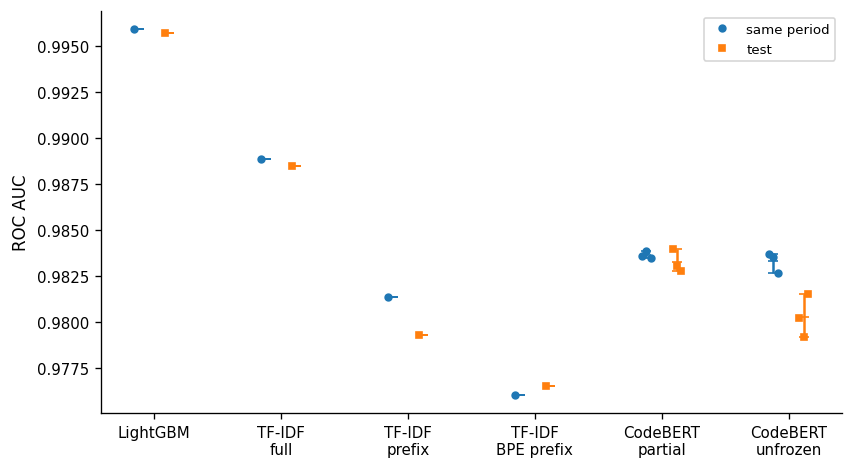

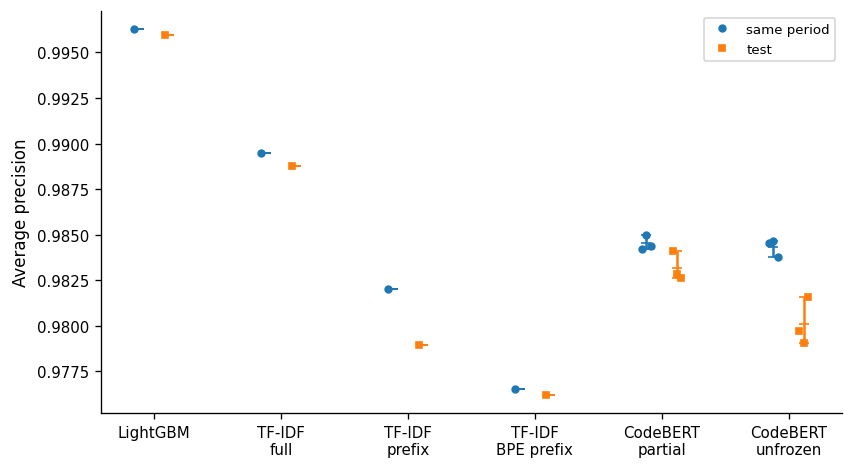

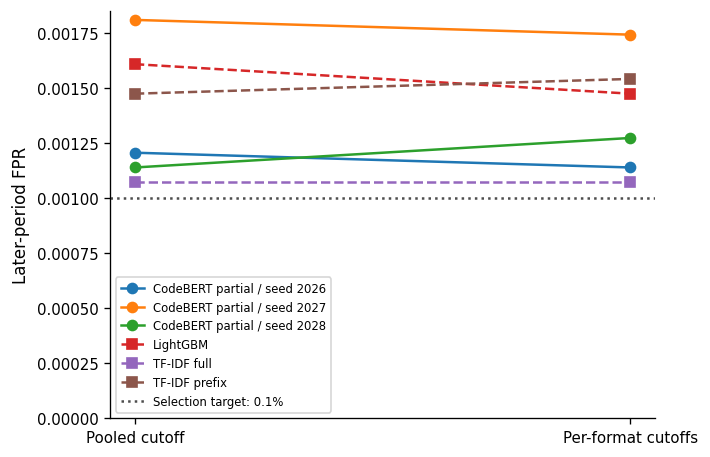

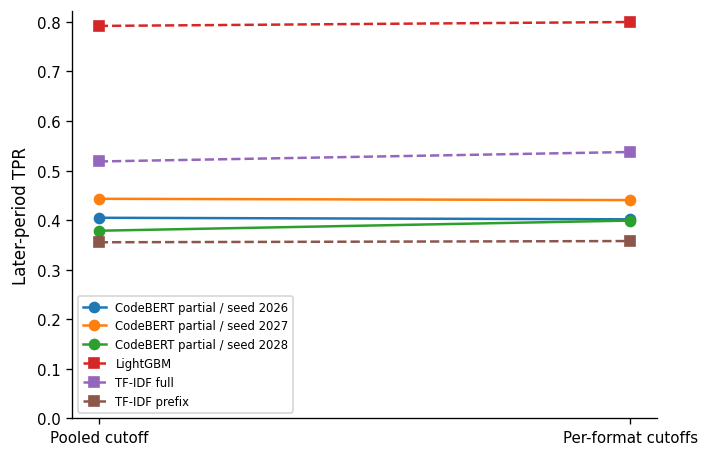

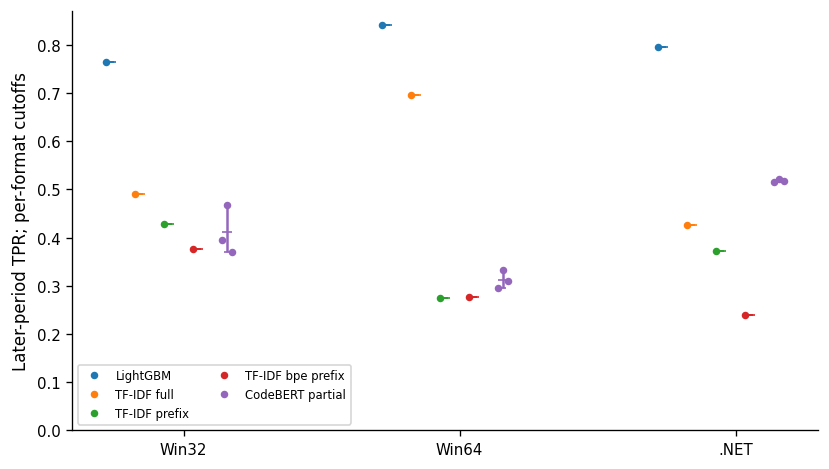

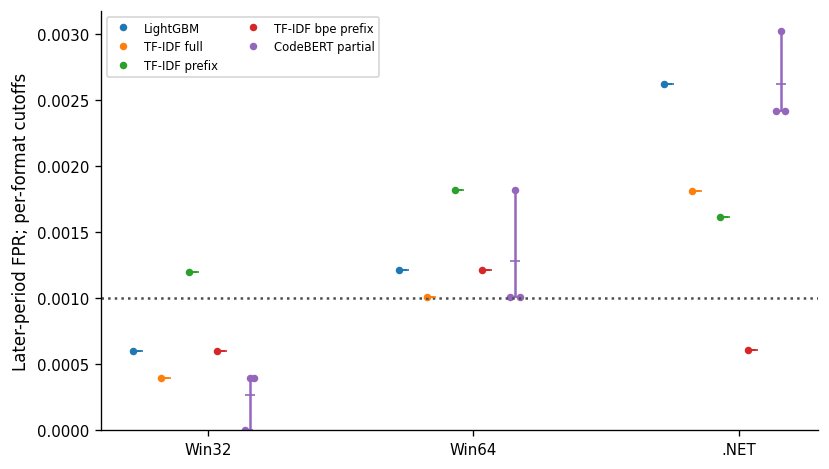

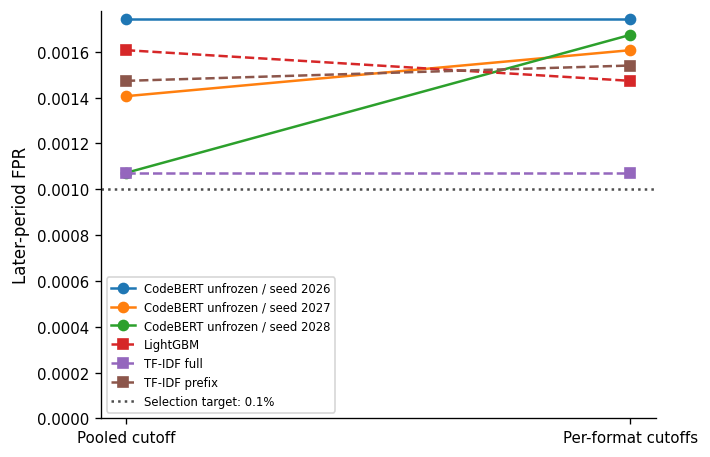

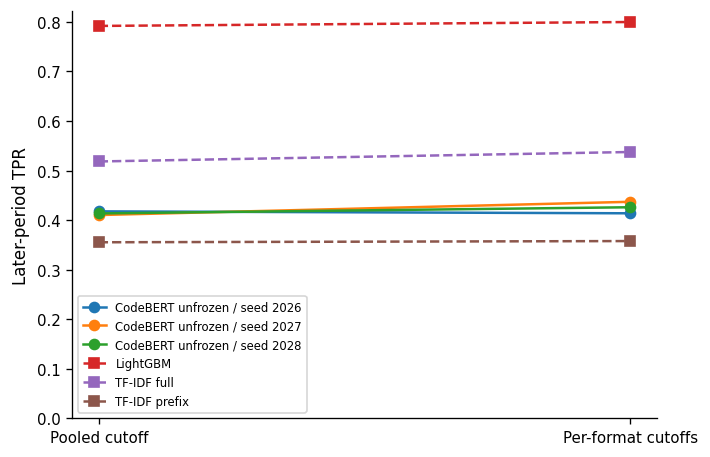

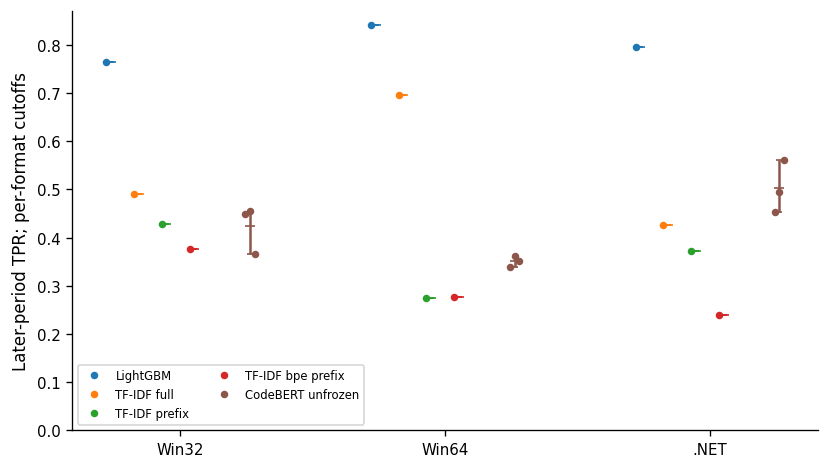

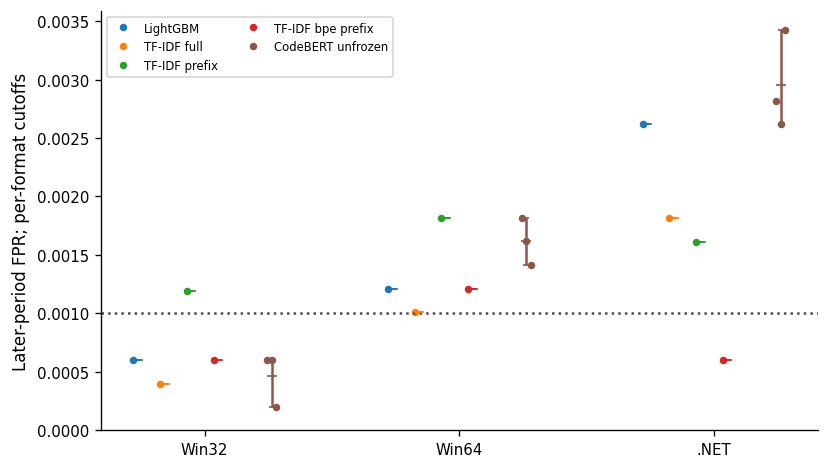

In [24]:
comparison_labels = ["LightGBM", "TF-IDF\nfull", "TF-IDF\nprefix", "TF-IDF\nBPE prefix", "CodeBERT\npartial", "CodeBERT\nunfrozen"]
for metric in ("ROC_AUC", "AP"):
    fig, ax = plt.subplots(figsize=(7.0, 3.8), layout="constrained")
    for j, (role, marker) in enumerate((("same_period", "o"), ("test", "s"))):
        for k, (_, names) in enumerate(model_groups):
            values = metrics[(metrics.model.isin(names)) & (metrics.role == role) & (metrics.subset == "Pooled")][metric].to_numpy()
            x = k + (j-.5)*.24
            ax.plot(x + np.linspace(-.035, .035, len(values)), values, marker, color=palette[j], markersize=4, label=role.replace("_", " ") if k == 0 else None)
            ax.errorbar(x, values.mean(), yerr=[[values.mean()-values.min()], [values.max()-values.mean()]], fmt="_", color=palette[j], capsize=3)
    ax.set_xticks(np.arange(len(comparison_labels)), comparison_labels)
    ax.set_ylabel("ROC AUC" if metric == "ROC_AUC" else "Average precision")
    ax.legend()
    save_figure(fig, "representation_comparison_"+metric.lower())

for variant in FREEZING:
    names = [f"CodeBERT_{variant}_s{s}" for s in TRAINING_SEEDS] + ["LightGBM", "TFIDF_full", "TFIDF_prefix"]
    for metric in ("FPR", "TPR"):
        fig, ax = plt.subplots(figsize=(5.8, 3.7), layout="constrained")
        for k, name in enumerate(names):
            block = deployment[(deployment.model == name) & (deployment.role == "test") & (deployment.subset == "Pooled") & (deployment.target_fpr == .001)].set_index("policy")
            ax.plot([0, 1], block.loc[["pooled", "per_format"], metric], ("o-" if name.startswith("CodeBERT") else "s--"), label=model_label(name), color=palette[k])
        if metric == "FPR":
            ax.axhline(.001, linestyle=":", color="0.3", label="Selection target: 0.1%")
        ax.set_xticks([0, 1], ["Pooled cutoff", "Per-format cutoffs"])
        ax.set_ylabel("Later-period "+metric)
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=7, loc="best")
        save_figure(fig, "threshold_policy_"+variant+"_"+metric.lower())
    for metric in ("TPR", "FPR"):
        fig, ax = plt.subplots(figsize=(6.8, 3.8), layout="constrained")
        for j, (family, members) in enumerate(model_groups):
            for k, ft in enumerate(FILE_TYPES):
                values = deployment[(deployment.model.isin(members)) & (deployment.role == "test") & (deployment.policy == "per_format") & (deployment.subset == ft) & (deployment.target_fpr == .001)][metric].to_numpy()
                if family in FREEZING and family != variant:
                    continue
                x = k + (j-2.5)*.105
                ax.plot(x + np.linspace(-.018, .018, len(values)), values, "o", markersize=3.5, color=palette[j], label=model_label(family) if k == 0 else None)
                ax.errorbar(x, values.mean(), yerr=[[values.mean()-values.min()], [values.max()-values.mean()]], fmt="_", color=palette[j], capsize=2)
        if metric == "FPR":
            ax.axhline(.001, linestyle=":", color="0.3")
        ax.set_xticks(np.arange(3), [format_labels[ft] for ft in FILE_TYPES])
        ax.set_ylabel("Later-period "+metric+"; per-format cutoffs")
        ax.set_ylim(bottom=0)
        ax.legend(ncol=2, fontsize=7)
        save_figure(fig, "format_comparison_"+variant+"_"+metric.lower())


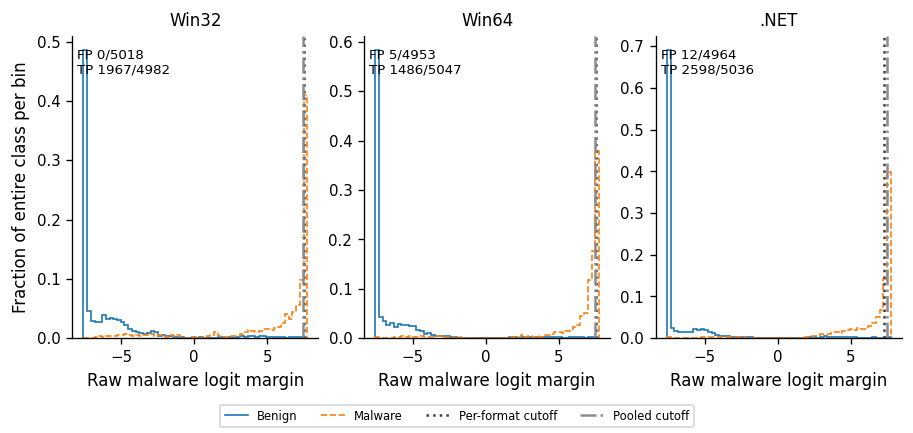

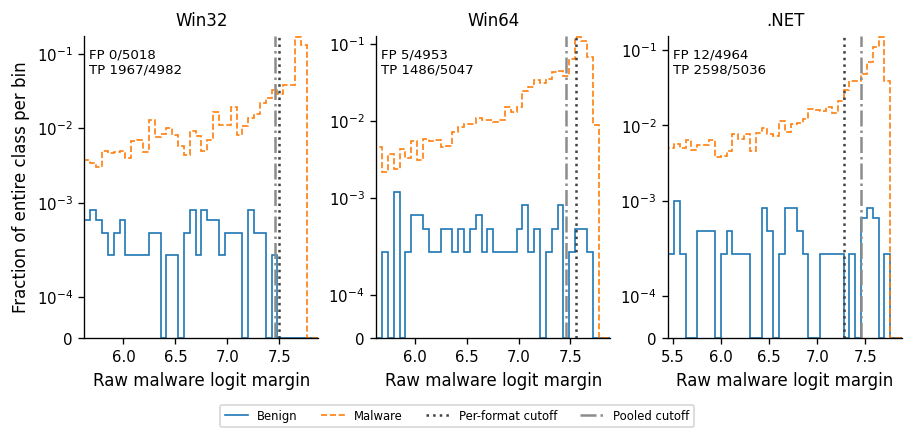

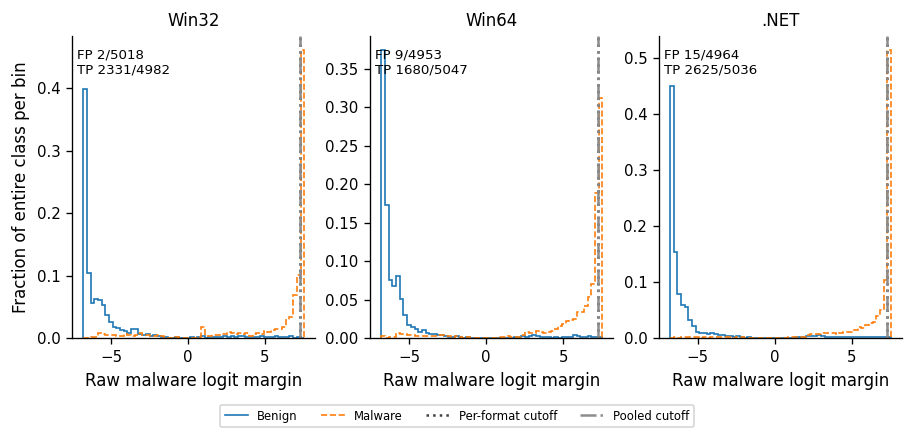

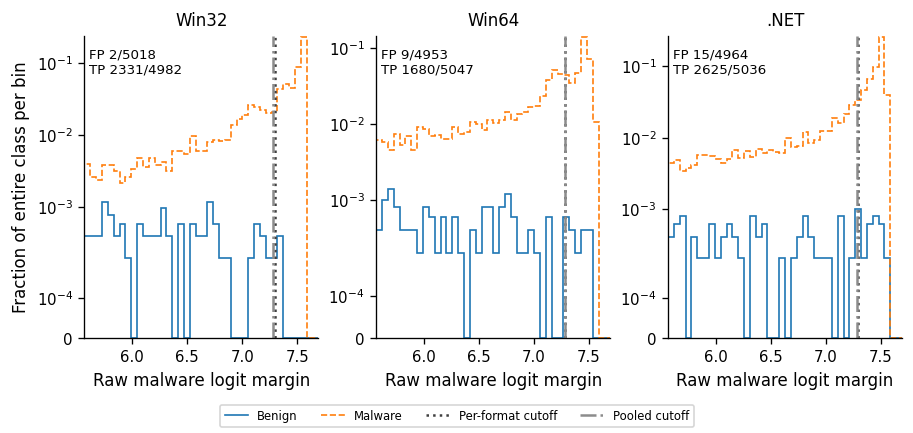

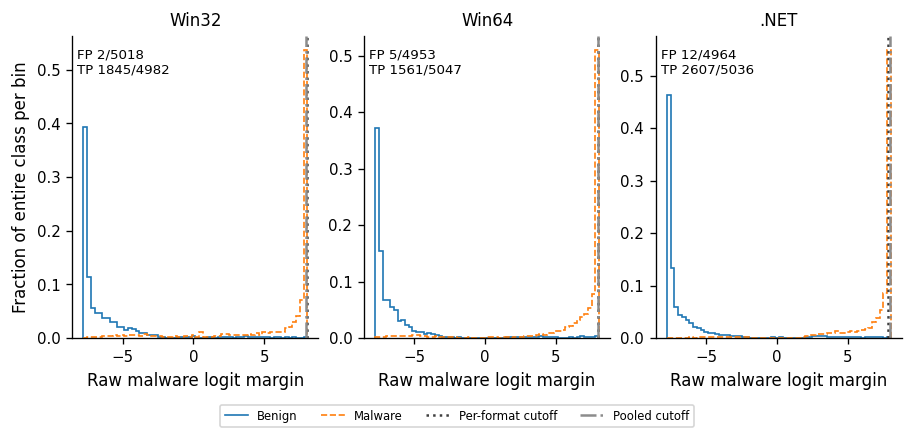

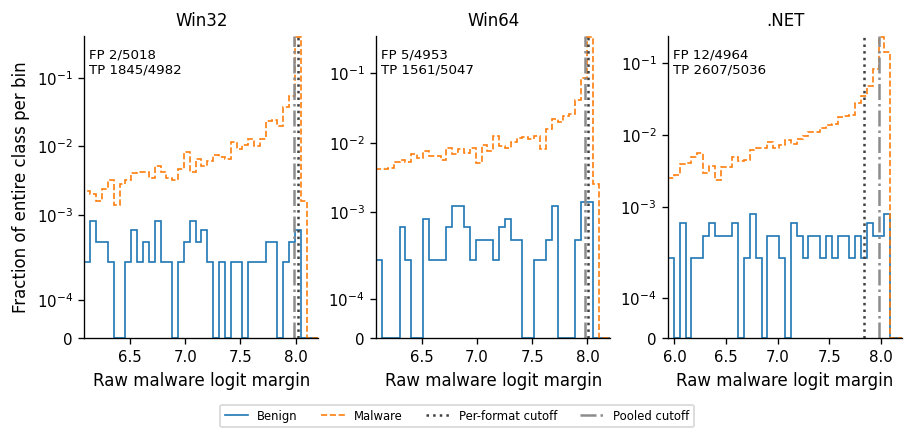

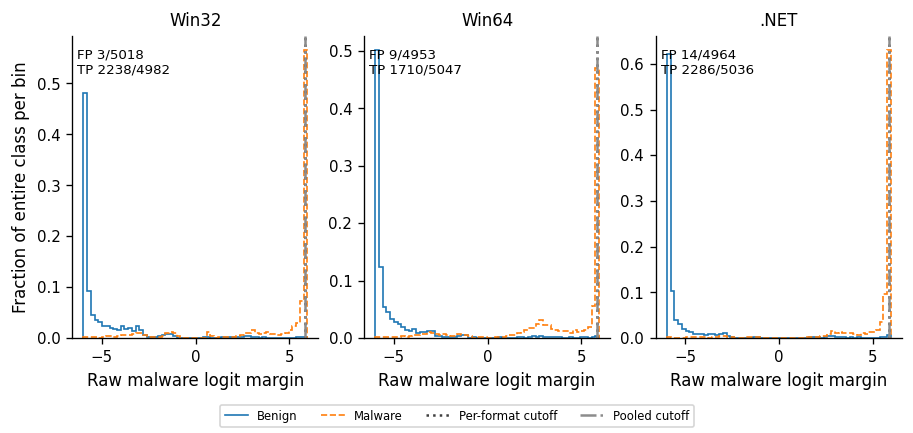

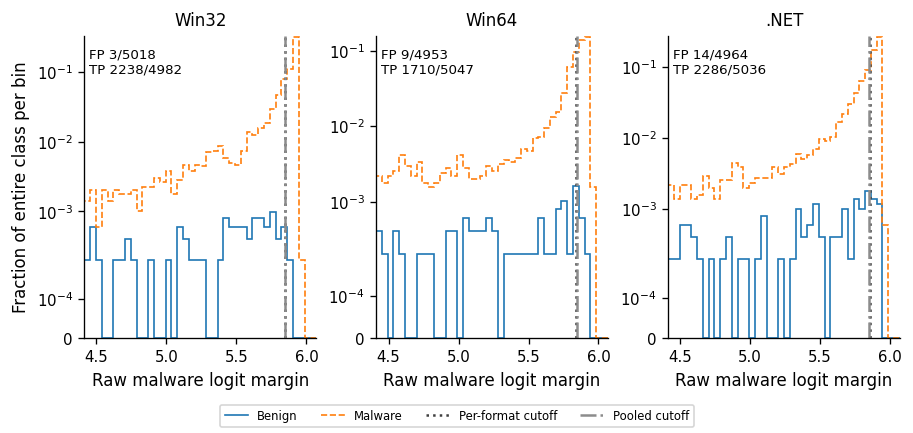

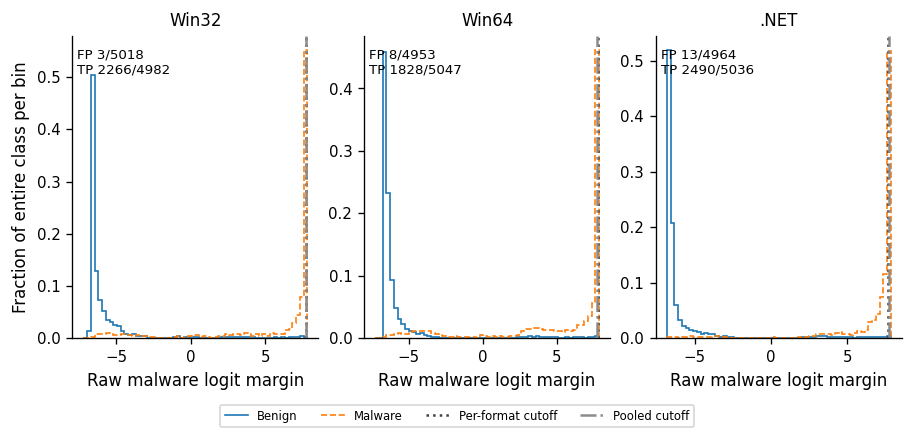

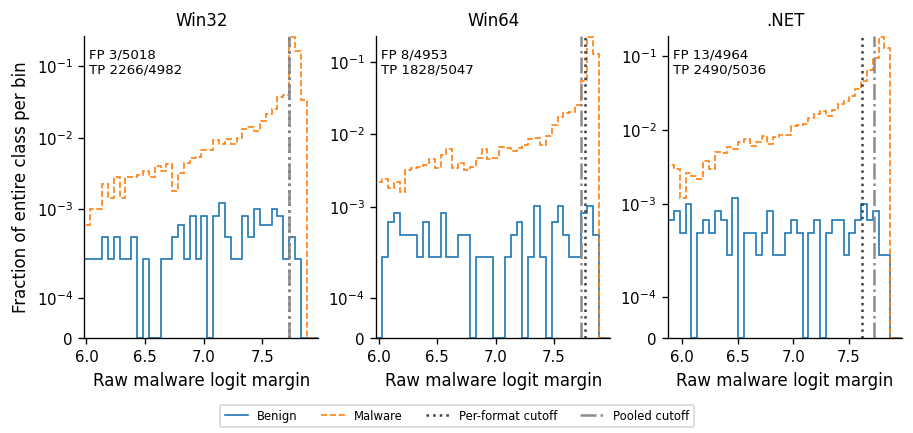

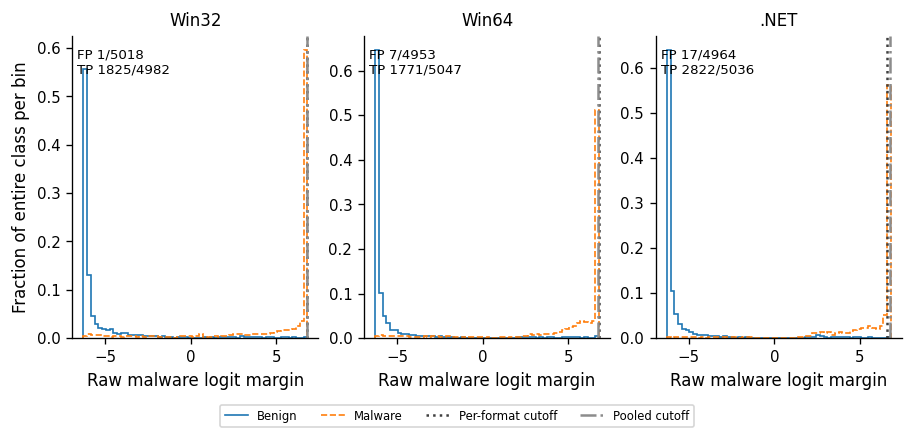

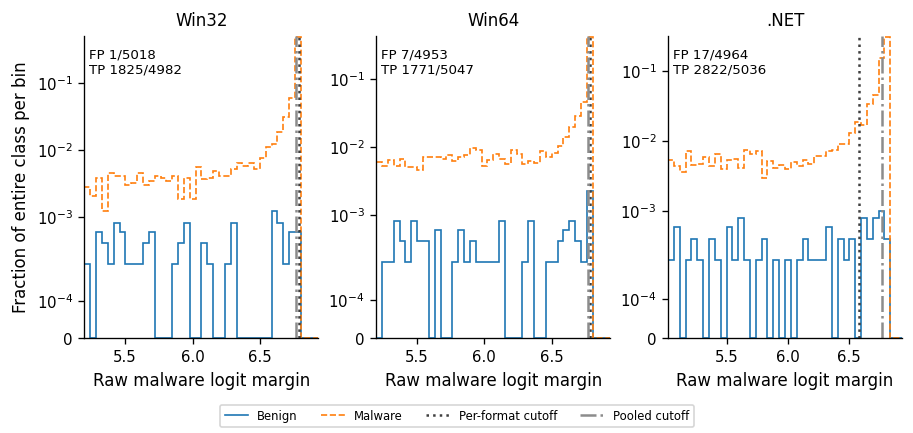

,model,file_type,label,class_total,plotted_count,omitted_below,omitted_above,per_format_cutoff,pooled_cutoff
0,CodeBERT_partial_s2026,Win32,0,5018,61,4957,0,7.493558,7.458154
1,CodeBERT_partial_s2026,Win32,1,4982,3624,1358,0,7.493558,7.458154
2,CodeBERT_partial_s2026,Win64,0,4953,60,4893,0,7.552785,7.458154
3,CodeBERT_partial_s2026,Win64,1,5047,4224,823,0,7.552785,7.458154
4,CodeBERT_partial_s2026,Dot_Net,0,4964,53,4911,0,7.278893,7.458154
5,CodeBERT_partial_s2026,Dot_Net,1,5036,3971,1065,0,7.278893,7.458154
6,CodeBERT_partial_s2027,Win32,0,5018,69,4949,0,7.296219,7.284322
7,CodeBERT_partial_s2027,Win32,1,4982,3714,1268,0,7.296219,7.284322
8,CodeBERT_partial_s2027,Win64,0,4953,84,4869,0,7.284322,7.284322
9,CodeBERT_partial_s2027,Win64,1,5047,3871,1176,0,7.284322,7.284322


In [25]:
histogram_rows, boundary_rows = [], []
for name in codebert_models:
    raw = scores[name]["test"]
    y, fmt = labels["test"], formats["test"]
    pool_cutoff = budget_threshold(labels["threshold"], scores[name]["threshold"], .001)
    for view in ("full", "boundary"):
        fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.5), layout="constrained")
        for k, (ax, ft) in enumerate(zip(axes, FILE_TYPES)):
            mask = fmt == ft
            select = formats["threshold"] == ft
            cutoff = budget_threshold(labels["threshold"][select], scores[name]["threshold"][select], .001)
            values = raw[mask]
            if view == "full":
                edges = np.linspace(values.min(), values.max(), 61)
            else:
                spread = max(float(np.quantile(values, .99)-np.quantile(values, .01)), 1e-6)
                lower = min(cutoff, pool_cutoff) - .12*spread
                upper = max(float(values.max()), cutoff, pool_cutoff) + .01*spread
                edges = np.linspace(lower, upper, 41)
            for cls, style, label in ((0, "-", "Benign"), (1, "--", "Malware")):
                v = raw[mask & (y == cls)]
                counts, _ = np.histogram(v, edges)
                ax.stairs(counts/len(v), edges, label=label, linestyle=style, color=palette[cls])
                histogram_rows.extend(dict(model=name, file_type=ft, view=view, label=cls, bin=i, left=edges[i], right=edges[i+1], count=int(n), class_total=len(v), fraction=n/len(v)) for i, n in enumerate(counts))
                if view == "boundary":
                    boundary_rows.append(dict(model=name, file_type=ft, label=cls, class_total=len(v), plotted_count=int(counts.sum()), omitted_below=int(np.sum(v < edges[0])), omitted_above=int(np.sum(v > edges[-1])), per_format_cutoff=cutoff, pooled_cutoff=pool_cutoff))
            ax.axvline(cutoff, linestyle=":", color="0.25", label="Per-format cutoff")
            ax.axvline(pool_cutoff, linestyle="-.", color="0.55", label="Pooled cutoff")
            fp = np.sum((values >= cutoff) & (y[mask] == 0))
            tp = np.sum((values >= cutoff) & (y[mask] == 1))
            n0, n1 = np.sum(y[mask] == 0), np.sum(y[mask] == 1)
            ax.set_title(format_labels[ft])
            ax.set_xlabel("Raw malware logit margin")
            ax.text(.02, .96, f"FP {fp}/{n0}\nTP {tp}/{n1}", transform=ax.transAxes, va="top", fontsize=8)
            if view == "boundary":
                ax.set_yscale("symlog", linthresh=1/max(n0, n1))
                ax.set_xlim(edges[0], edges[-1])
            if k == 0:
                ax.set_ylabel("Fraction of entire class per bin")
        fig.legend(*axes[-1].get_legend_handles_labels(), loc="outside lower center", ncol=4, fontsize=7)
        save_figure(fig, "score_"+view+"_"+name)
score_histograms = save_table(pd.DataFrame(histogram_rows), "score_histograms")
save_table(pd.DataFrame(boundary_rows), "score_boundary_counts")


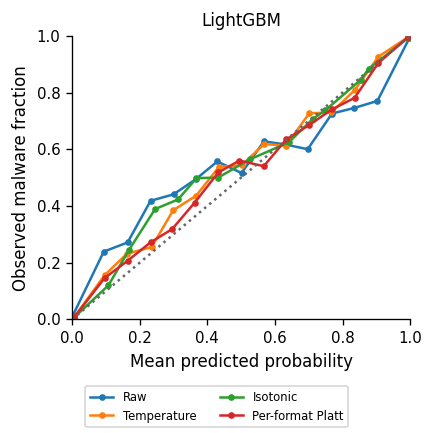

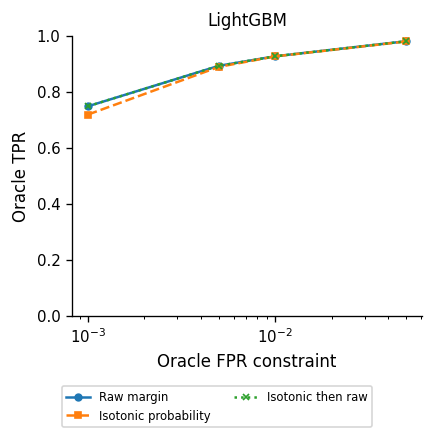

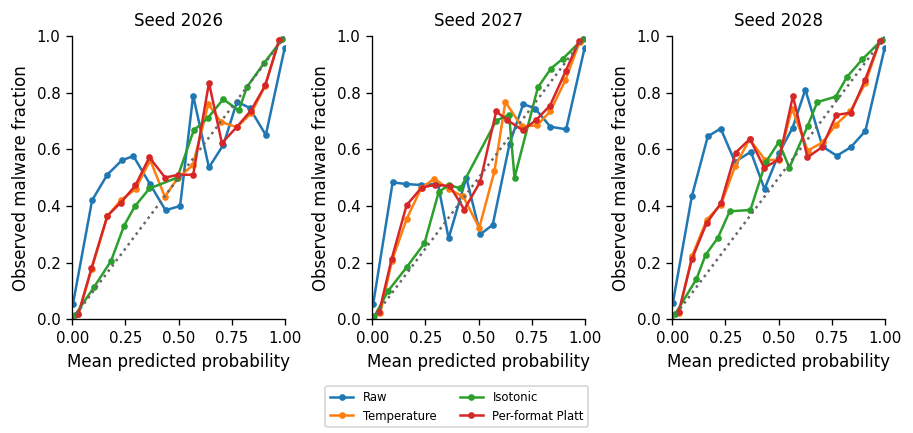

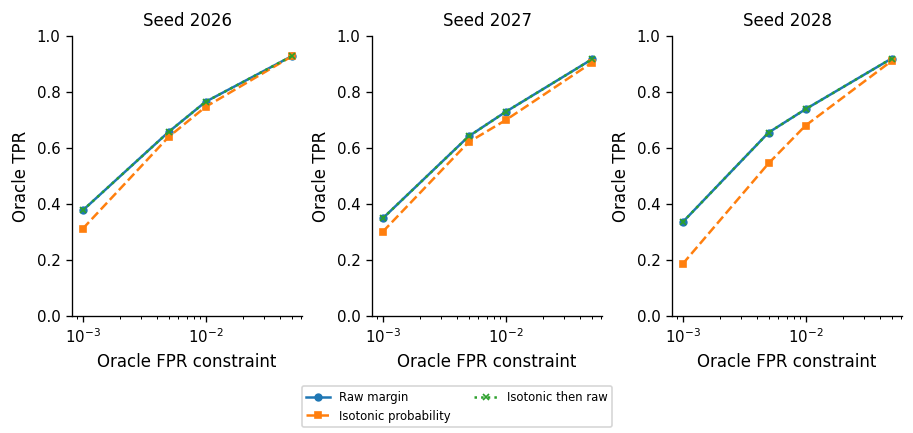

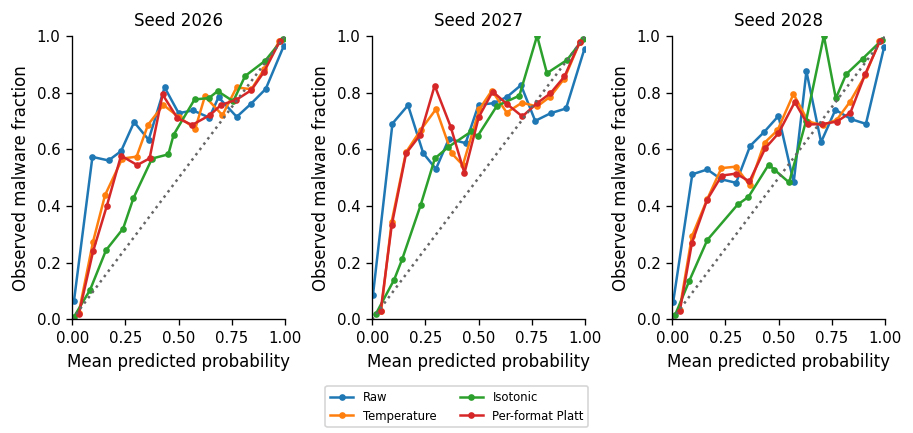

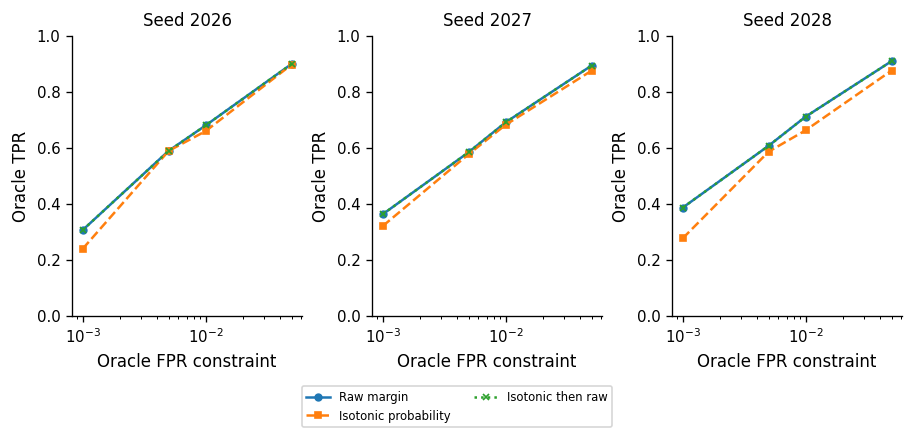

In [26]:
reliability_rows = []
for name in base_models:
    for suffix, method in (("", "Raw"), ("__temperature", "Temperature"), ("__isotonic", "Isotonic"), ("__format_platt", "Per-format Platt")):
        probability = probabilities[name+suffix]["test"]
        which = np.minimum((probability*15).astype(int), 14)
        for k in range(15):
            mask = which == k
            if mask.any():
                reliability_rows.append(dict(model=name, method=method, bin=k, n=int(mask.sum()), mean_probability=float(probability[mask].mean()), malware_fraction=float(labels["test"][mask].mean())))
reliability_bins = save_table(pd.DataFrame(reliability_rows), "reliability_bins")
calibration_groups = [("LightGBM", ["LightGBM"])] + [(variant, [f"CodeBERT_{variant}_s{s}" for s in TRAINING_SEEDS]) for variant in FREEZING]
for group, names in calibration_groups:
    fig, axes = plt.subplots(1, len(names), figsize=(max(3.5, 2.5*len(names)), 3.5), layout="constrained", squeeze=False)
    for ax, name in zip(axes.flat, names):
        for k, method in enumerate(("Raw", "Temperature", "Isotonic", "Per-format Platt")):
            b = reliability_bins[(reliability_bins.model == name) & (reliability_bins.method == method)]
            ax.plot(b.mean_probability, b.malware_fraction, "o-", markersize=3, label=method, color=palette[k])
        ax.plot([0, 1], [0, 1], ":", color="0.4")
        ax.set(xlabel="Mean predicted probability", ylabel="Observed malware fraction", xlim=(0, 1), ylim=(0, 1))
        ax.set_title("Seed "+name.rsplit("_s", 1)[-1] if name.startswith("CodeBERT") else name)
    fig.legend(*axes.flat[-1].get_legend_handles_labels(), loc="outside lower center", ncol=2, fontsize=7)
    save_figure(fig, "probability_reliability_"+group)
    fig, axes = plt.subplots(1, len(names), figsize=(max(3.5, 2.5*len(names)), 3.5), layout="constrained", squeeze=False)
    for ax, name in zip(axes.flat, names):
        for suffix, marker, method in (("", "o-", "Raw margin"), ("__isotonic", "s--", "Isotonic probability"), ("__isotonic_tiebreak", "x:", "Isotonic then raw")):
            b = oracle_table[(oracle_table.model == name+suffix) & (oracle_table.role == "test") & (oracle_table.subset == "Pooled") & (oracle_table.policy == "pooled")].sort_values("target_fpr")
            ax.plot(b.target_fpr, b.TPR, marker, label=method, markersize=4)
        ax.set_xscale("log")
        ax.set(xlabel="Oracle FPR constraint", ylabel="Oracle TPR", ylim=(0, 1))
        ax.set_title("Seed "+name.rsplit("_s", 1)[-1] if name.startswith("CodeBERT") else name)
    fig.legend(*axes.flat[-1].get_legend_handles_labels(), loc="outside lower center", ncol=2, fontsize=7)
    save_figure(fig, "isotonic_ranking_"+group)


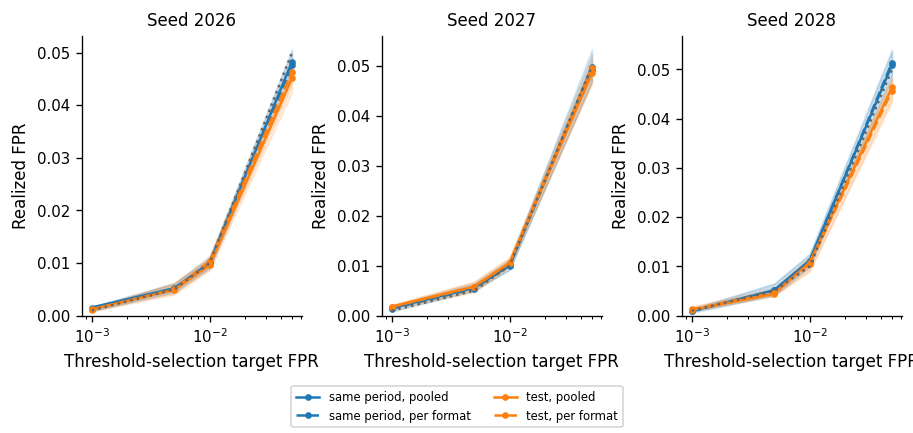

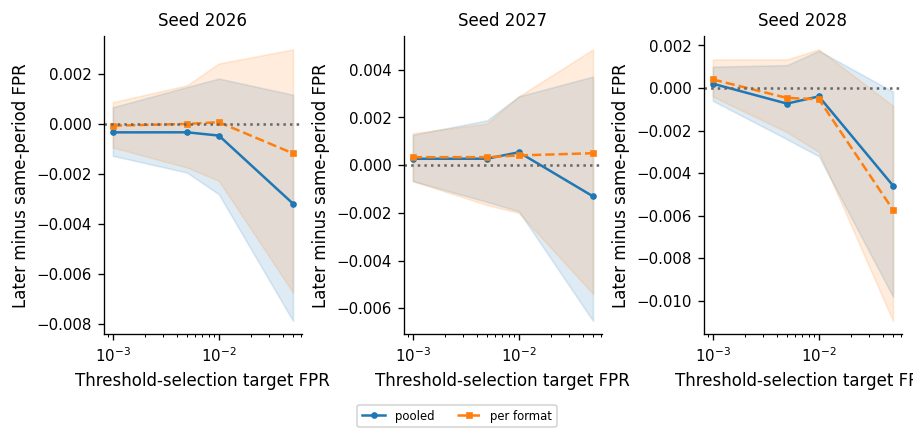

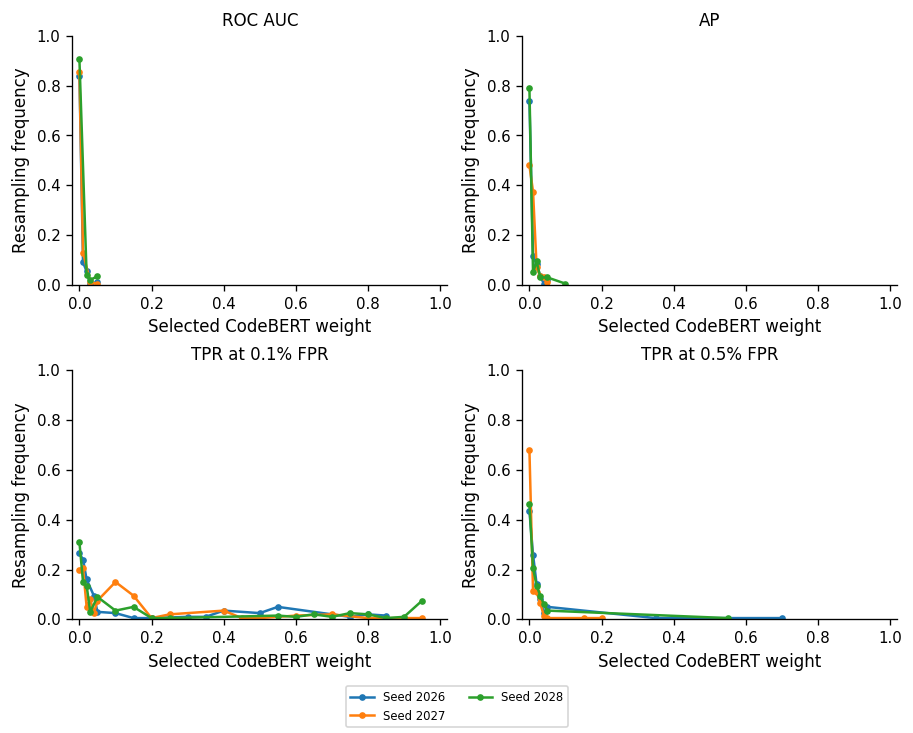

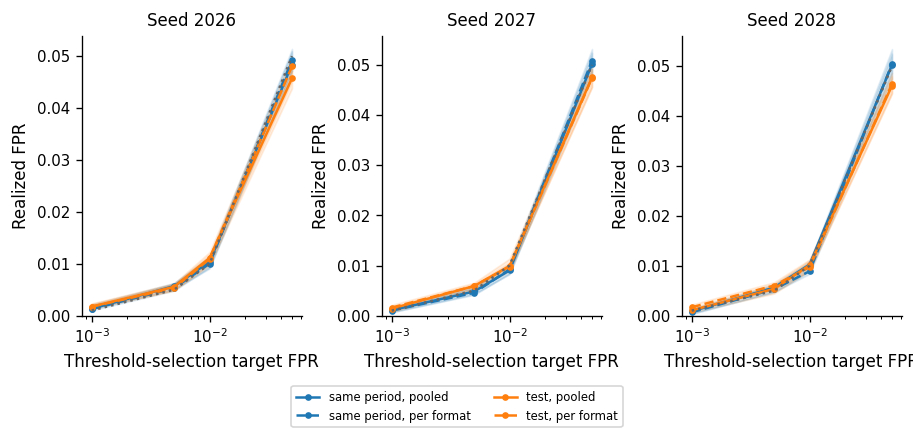

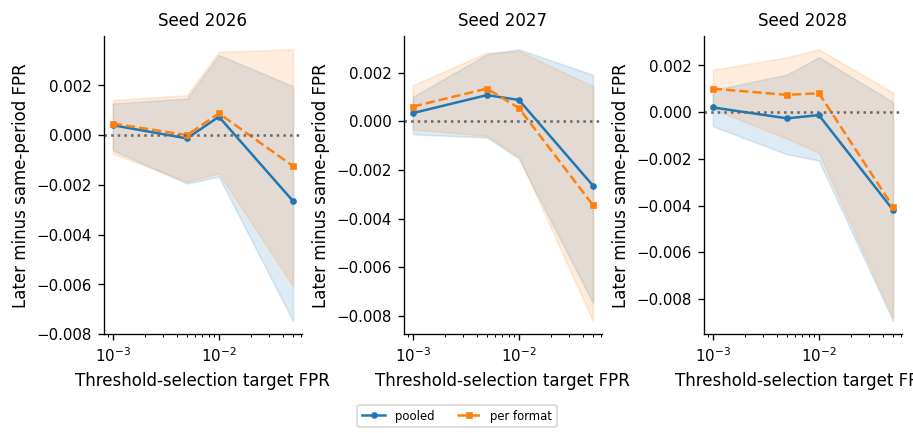

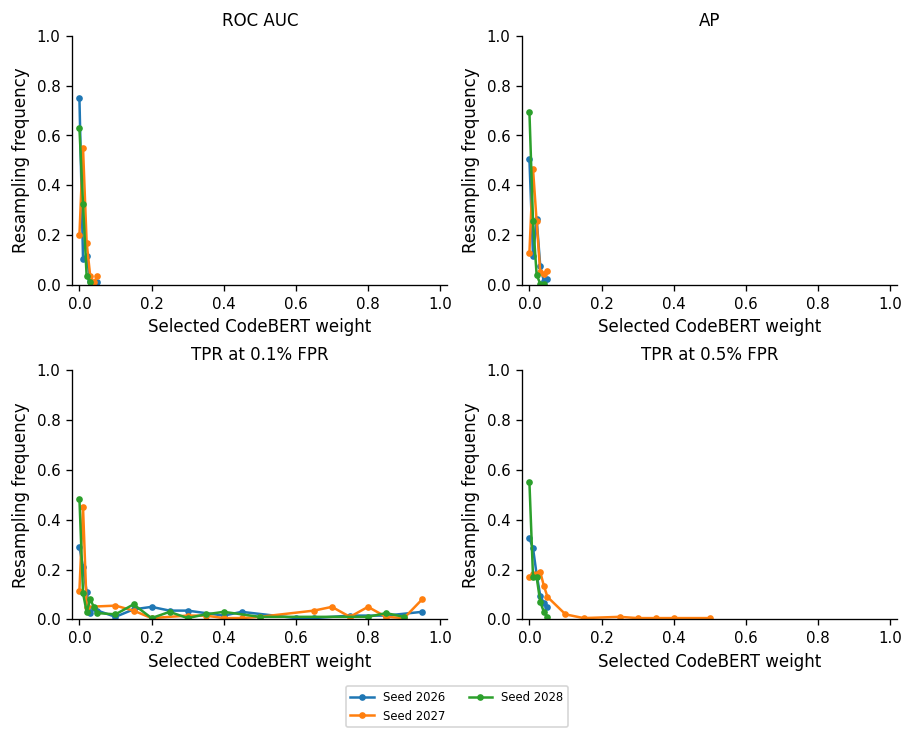

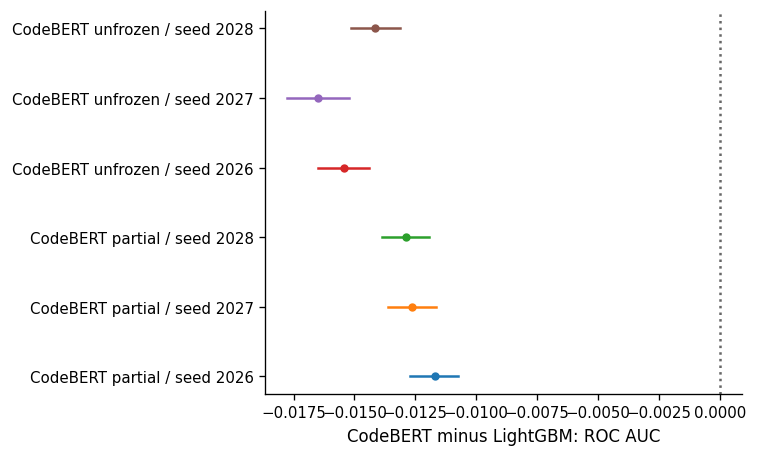

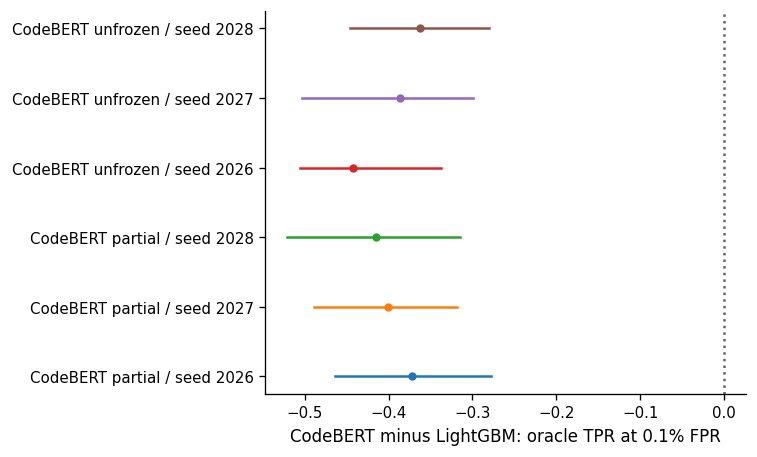

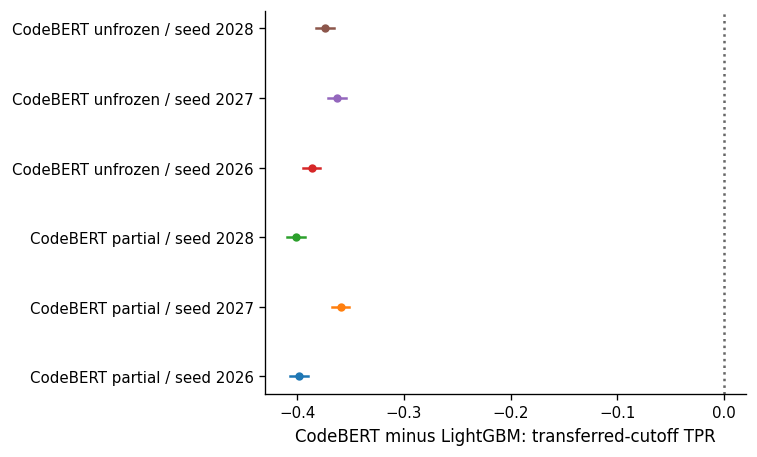

In [27]:
for variant in FREEZING:
    fig, axes = plt.subplots(1, len(TRAINING_SEEDS), figsize=(7.5, 3.5), layout="constrained", squeeze=False)
    for ax, seed in zip(axes.flat, TRAINING_SEEDS):
        name = f"CodeBERT_{variant}_s{seed}"
        for j, role in enumerate(("same_period", "test")):
            for policy, style in (("pooled", "-"), ("per_format", "--")):
                b = transfer_summary[(transfer_summary.model == name) & (transfer_summary.policy == policy) & (transfer_summary.metric == role+"_FPR") & (transfer_summary.scope == "threshold_only_fixed_evaluation")].sort_values("target_fpr")
                ax.plot(b.target_fpr, b.observed, style, marker="o", markersize=3, color=palette[j], label=role.replace("_", " ")+", "+policy.replace("_", " "))
                ax.fill_between(b.target_fpr.to_numpy(), b.percentile_lo.to_numpy(), b.percentile_hi.to_numpy(), color=palette[j], alpha=.12)
        ax.plot(FPR_TARGETS, FPR_TARGETS, ":", color="0.4")
        ax.set_xscale("log")
        ax.set(xlabel="Threshold-selection target FPR", ylabel="Realized FPR", ylim=(0, None))
        ax.set_title(f"Seed {seed}")
    fig.legend(*axes.flat[-1].get_legend_handles_labels(), loc="outside lower center", ncol=2, fontsize=7)
    save_figure(fig, "threshold_transfer_"+variant)

    fig, axes = plt.subplots(1, len(TRAINING_SEEDS), figsize=(7.5, 3.5), layout="constrained", squeeze=False)
    for ax, seed in zip(axes.flat, TRAINING_SEEDS):
        name = f"CodeBERT_{variant}_s{seed}"
        for j, policy in enumerate(("pooled", "per_format")):
            b = transfer_summary[(transfer_summary.model == name) & (transfer_summary.policy == policy) & (transfer_summary.metric == "test_minus_same_FPR") & (transfer_summary.scope == "threshold_and_evaluation_sampling")].sort_values("target_fpr")
            ax.plot(b.target_fpr, b.observed, "o-" if j == 0 else "s--", markersize=3, label=policy.replace("_", " "), color=palette[j])
            ax.fill_between(b.target_fpr.to_numpy(), b.percentile_lo.to_numpy(), b.percentile_hi.to_numpy(), color=palette[j], alpha=.14)
        ax.axhline(0, linestyle=":", color="0.4")
        ax.set_xscale("log")
        ax.set(xlabel="Threshold-selection target FPR", ylabel="Later minus same-period FPR")
        ax.set_title(f"Seed {seed}")
    fig.legend(*axes.flat[-1].get_legend_handles_labels(), loc="outside lower center", ncol=2, fontsize=7)
    save_figure(fig, "temporal_difference_"+variant)

    fig, axes = plt.subplots(2, 2, figsize=(7.5, 6.0), layout="constrained")
    for ax, objective in zip(axes.flat, FUSION_OBJECTIVES):
        for seed in TRAINING_SEEDS:
            name = f"CodeBERT_{variant}_s{seed}"
            b = weight_frequency[(weight_frequency.model == name) & (weight_frequency.method == "fusion_"+objective)].sort_values("value")
            ax.plot(b.value, b.selected_fraction, "o-", markersize=3, label=f"Seed {seed}")
        ax.set(xlabel="Selected CodeBERT weight", ylabel="Resampling frequency", xlim=(-.02, 1.02), ylim=(0, 1))
        ax.set_title(objective.replace("ROC_AUC", "ROC AUC").replace("TPR_0.001", "TPR at 0.1% FPR").replace("TPR_0.005", "TPR at 0.5% FPR"))
    fig.legend(*axes.flat[-1].get_legend_handles_labels(), loc="outside lower center", ncol=2, fontsize=7)
    save_figure(fig, "fusion_selection_"+variant)

for metric in ("ROC_AUC", "oracle_pooled_TPR_0.001", "fixed_per_format_TPR_0.001"):
    b = paired_summary[(paired_summary.left.isin(codebert_models)) & (paired_summary.right == "LightGBM") & (paired_summary.metric == metric)].set_index("left").reindex(codebert_models)
    fig, ax = plt.subplots(figsize=(6.2, 3.7), layout="constrained")
    for k, name in enumerate(codebert_models):
        row = b.loc[name]
        ax.plot([row.percentile_lo, row.percentile_hi], [k, k], color=palette[k%len(palette)])
        ax.plot(row.observed_difference, k, "o", color=palette[k%len(palette)], markersize=4)
    ax.axvline(0, linestyle=":", color="0.4")
    ax.set_yticks(np.arange(len(codebert_models)), [model_label(n) for n in codebert_models])
    ax.set_xlabel("CodeBERT minus LightGBM: "+{"ROC_AUC": "ROC AUC", "oracle_pooled_TPR_0.001": "oracle TPR at 0.1% FPR", "fixed_per_format_TPR_0.001": "transferred-cutoff TPR"}[metric])
    save_figure(fig, "paired_difference_"+metric.lower())


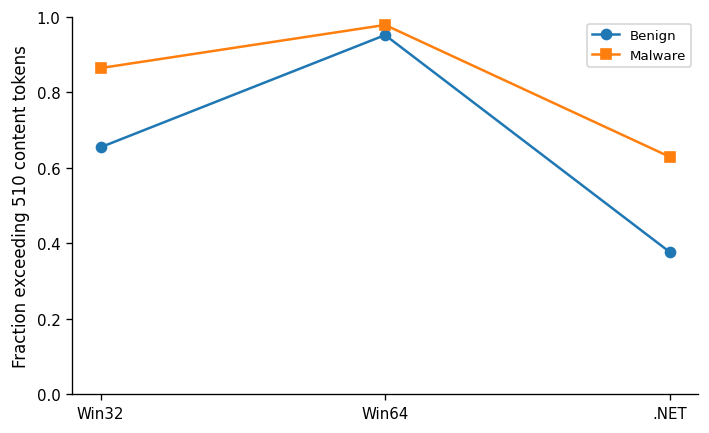

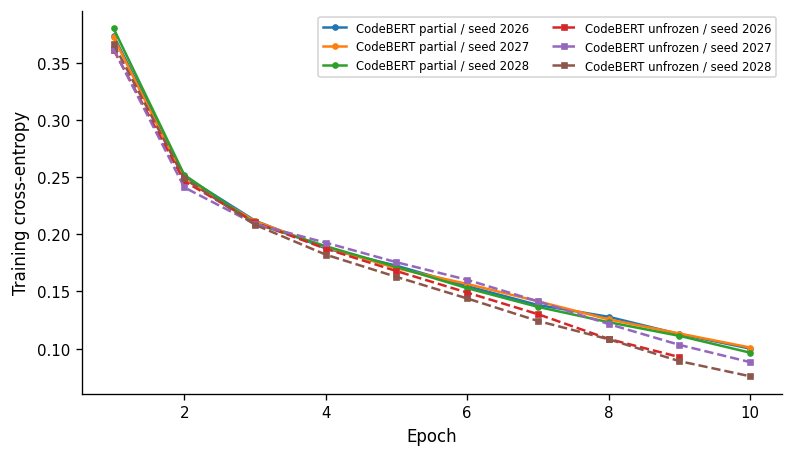

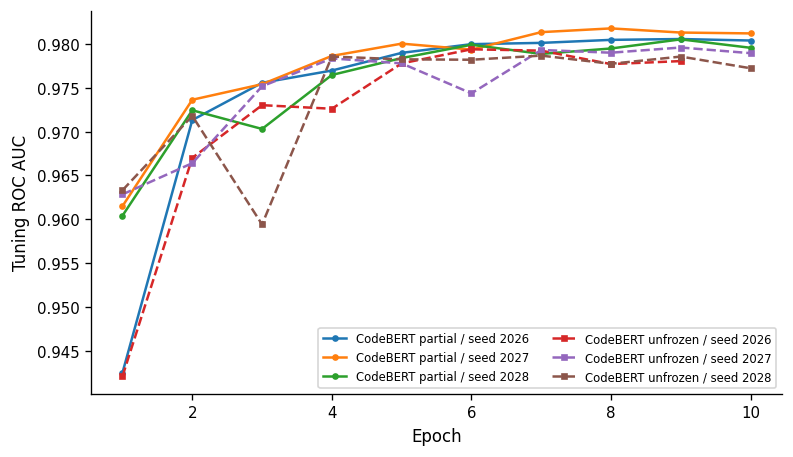

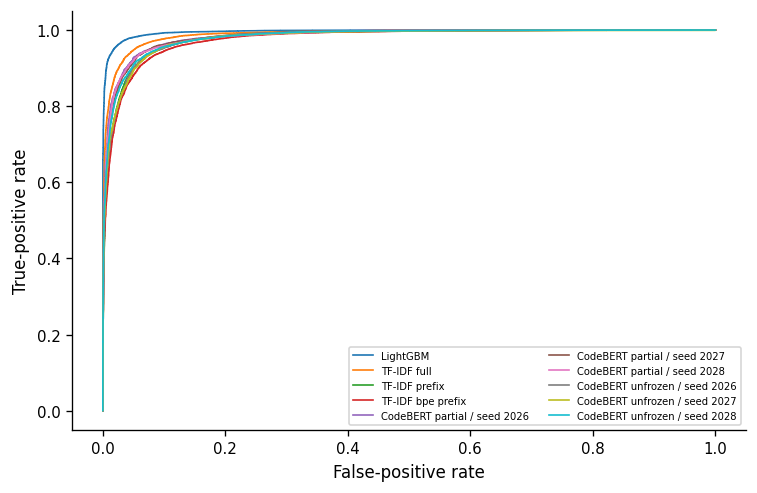

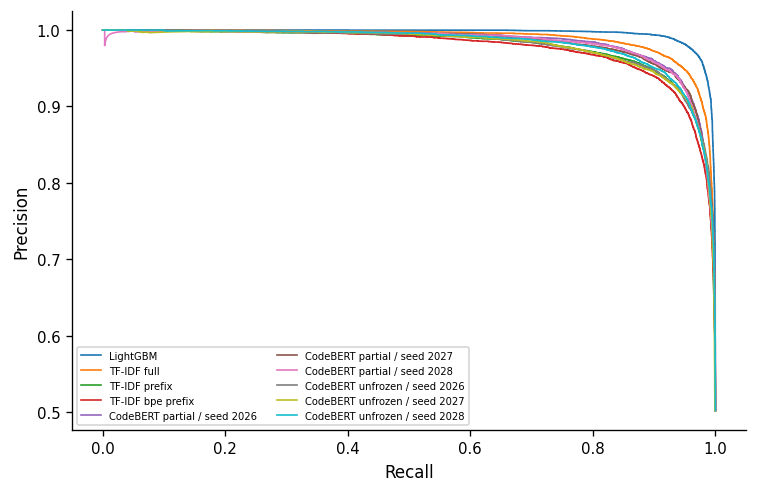

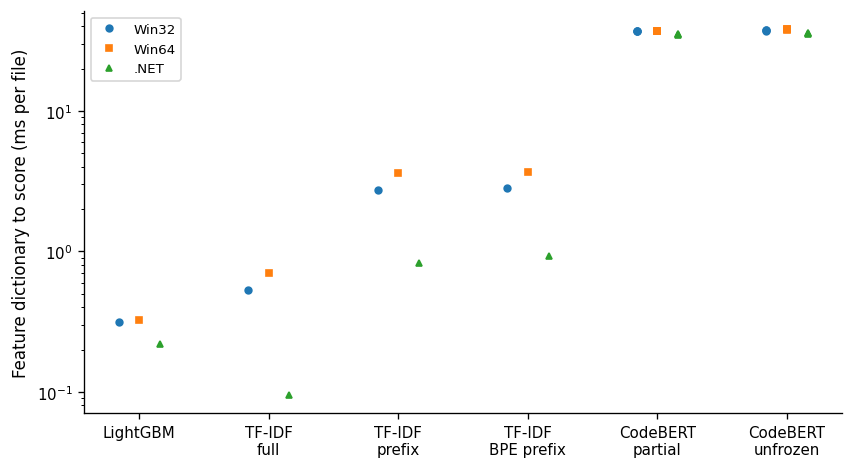

In [28]:
fig, ax = plt.subplots(figsize=(5.8, 3.5), layout="constrained")
for cls, marker in ((0, "o"), (1, "s")):
    b = truncation_summary[(truncation_summary.role == "test") & (truncation_summary.label == cls)].set_index("file_type").reindex(FILE_TYPES)
    ax.plot(np.arange(3), b.truncation_fraction, marker+"-", label="Benign" if cls == 0 else "Malware")
ax.set_xticks(np.arange(3), [format_labels[ft] for ft in FILE_TYPES])
ax.set_ylabel(f"Fraction exceeding {CONTENT_LIMIT} content tokens")
ax.set_ylim(0, 1)
ax.legend()
save_figure(fig, "input_truncation")

for observable in ("train_loss", "tune_ROC_AUC"):
    fig, ax = plt.subplots(figsize=(6.5, 3.7), layout="constrained")
    for name in codebert_models:
        h = pd.read_csv(DATA_DIR / f"training_{name}.csv", float_precision="round_trip")
        ax.plot(h.epoch, h[observable], "o-" if "partial" in name else "s--", markersize=3, label=model_label(name))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training cross-entropy" if observable == "train_loss" else "Tuning ROC AUC")
    ax.legend(ncol=2, fontsize=7)
    save_figure(fig, "training_"+observable.lower())

for observable in ("roc", "precision_recall"):
    fig, ax = plt.subplots(figsize=(6.2, 4.0), layout="constrained")
    for name in base_models:
        if observable == "roc":
            x, y, _ = roc_curve(labels["test"], scores[name]["test"])
        else:
            y, x, _ = precision_recall_curve(labels["test"], scores[name]["test"])
        ax.plot(x, y, label=model_label(name), linewidth=1)
    ax.set(xlabel="False-positive rate" if observable == "roc" else "Recall", ylabel="True-positive rate" if observable == "roc" else "Precision")
    ax.legend(fontsize=6, ncol=2, loc="lower right" if observable == "roc" else "lower left")
    save_figure(fig, "test_"+observable)

latency = pd.read_csv(DATA_DIR / "inference_time_summary.csv", float_precision="round_trip")
fig, ax = plt.subplots(figsize=(7.0, 3.8), layout="constrained")
for j, ft in enumerate(FILE_TYPES):
    for k, (group, members) in enumerate(model_groups):
        component = "feature_dictionary_to_margin_FP32" if group in FREEZING else "feature_dictionary_to_margin"
        b = latency[(latency.model.isin(members)) & (latency.file_type == ft) & (latency.component == component) & (latency.batch_size > 1)]
        x = k+(j-1)*.16
        ax.plot(np.repeat(x, len(b)), b["median"], "os^"[j], color=palette[j], markersize=4, label=format_labels[ft] if k == 0 else None)
ax.set_xticks(np.arange(6), comparison_labels)
ax.set_yscale("log")
ax.set_ylabel("Feature dictionary to score (ms per file)")
ax.legend()
save_figure(fig, "inference_time")


## Exports


In [29]:
save_table(pd.DataFrame([dict(model=name, **info) for name, info in model_info.items()]), "model_catalog")
assert len(base_models) == 4 + len(FREEZING) * len(TRAINING_SEEDS)
assert samples.sample_id.is_unique
assert not metrics[["ROC_AUC", "AP", "Brier", "ECE"]].isna().any().any()
assert (threshold_table.achieved_fp <= threshold_table.allowed_fp).all()
assert all(row["lexicographic_order_equals_raw"] for row in isotonic_tie_audit)

archives = []
for directory, names in ((DATA_DIR, data_files), (FIGURES_DIR, figure_files)):
    archive = ROOT / f"{directory.name}.zip"
    with zipfile.ZipFile(archive, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=9) as z:
        for name in sorted(names):
            z.write(directory / name, arcname=f"{directory.name}/{name}")
    archives.append(dict(archive=archive.name, files=len(names), megabytes=archive.stat().st_size / 1e6))
display(pd.DataFrame(archives))


,archive,files,megabytes
0,data.zip,55,29.278432
1,figures.zip,43,0.750547
